# Urdu Question Answering with Seq2Seq and Attention

### Mounting Google Drive

In [76]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Import Libraries

In [6]:
!pip install datasets sentencepiece sacrebleu rouge-score torch

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 12.8 MB/s eta 0:00:00
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24986 sha256=45522322411b0320c17cf7d9ea302ef47de7c0b071c281a43c7482f41c06c2dd
  Stored in directory: /root/.cache/pip/wheels/44/af/da/5ffc433e2786f0b1a9c6f458d5fb8f611d8eb332387f18698f
Successfully built rouge-score


In [7]:
from datasets import load_dataset
import csv
import sentencepiece as spm
import torch
import sacrebleu
from rouge_score import rouge_scorer

import os
import math
import random
import sentencepiece as spm
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

### Constant Values

In [8]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

VOCAB_SIZE = 8000
EMBED_SIZE = 256
HIDDEN_SIZE = 512
NUM_LAYERS = 2
DROPOUT = 0.3

BATCH_SIZE = 64
EPOCHS = 15
LEARNING_RATE = 1e-3
TEACHER_FORCING_RATIO = 0.5

PAD_ID = 0
UNK_ID = 1
BOS_ID = 2
EOS_ID = 3

OUTPUT = '/content/drive/MyDrive/Gen AI Assignments/A1/v3'
os.makedirs(OUTPUT, exist_ok=True)

cuda


### Load Dataset

In [9]:
ds = load_dataset ("uqa/UQA") # splits : train , validation

README.md:   0%|          | 0.00/898 [00:00<?, ?B/s]

data/train-00000-of-00001-bac007e8ca7192(…): reconstructing file:   0%|          |  0.00B / 30.2MB            

data/train-00000-of-00001-bac007e8ca7192(…): downloading bytes:           |  0.00B            

data/validation-00000-of-00001-cf8a6960d(…): reconstructing file:   0%|          |  0.00B / 2.92MB            

data/validation-00000-of-00001-cf8a6960d(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/124745 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/16824 [00:00<?, ? examples/s]

In [10]:
print (ds)

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'is_impossible', 'answer', 'answer_start'],
        num_rows: 124745
    })
    validation: Dataset({
        features: ['id', 'title', 'context', 'question', 'is_impossible', 'answer', 'answer_start'],
        num_rows: 16824
    })
})


In [11]:
ex = ds["train"][1]
print (ex.keys()) # id , title , context , question, answer
print (ex["question"])
print (ex["answer"]) # { ’ text ’: [...] , ’ answer_start ’: [...]}

dict_keys(['id', 'title', 'context', 'question', 'is_impossible', 'answer', 'answer_start'])
جب وہ بڑی ہو رہی تھی تو بیونس نے کن شعبوں میں مقابلہ کیا؟
گانے اور رقص


In [12]:
ds["train"]["answer"]

Column(['1990 کی دہائی کے آخر میں', 'گانے اور رقص', '2003', 'ہیوسٹن ، ٹیکساس', '1990 کی دہائی کے آخر میں', ...])

### Extracting answerable questions

In [13]:
n_total = len(ds["train"])
n_ans = sum(len(a) > 0 for a in ds["train"]["answer"])
print ( f" train rows : { n_total } , answerable : { n_ans }")

 train rows : 124745 , answerable : 83018


In [14]:
ds['train'][0]

{'id': '56be85543aeaaa14008c9063',
 'title': 'بیونسے',
 'context': "Beyoncé Giselle Knowles-Carter (/biː'j ⁇ nseɪ/ bee-YON-say) (پیدائش 4 ستمبر 1981) ایک امریکی گلوکارہ ، گانا لکھنے والی ، ریکارڈ پروڈیوسر اور اداکارہ ہیں۔ ہیوسٹن ، ٹیکساس میں پیدا ہوئی اور اس کی پرورش ہوئی ، اس نے بچپن میں مختلف گانے اور رقص کے مقابلوں میں پرفارم کیا ، اور 1990 کی دہائی کے آخر میں R&B گرل گروپ ڈسٹنی چائلڈ کے لیڈ گلوکار کی حیثیت سے شہرت حاصل کی۔ اس کے والد ، میتھیو نولز کے زیر انتظام ، یہ گروپ دنیا کے سب سے زیادہ فروخت ہونے والے گرل گروپس میں سے ایک بن گیا۔ ان کے وقفے نے بیونس کی پہلی البم ، خطرناک طور پر محبت میں (2003) کی رہائی دیکھی ، جس نے اسے دنیا بھر میں ایک سولو آرٹسٹ کے طور پر قائم کیا ، پانچ گریمی ایوارڈز حاصل کیے اور بل بورڈ ہاٹ 100 میں نمبر ون سنگلز میں محبت اور بچے پاگل لڑکے۔",
 'question': 'بیونس نے کب مقبولیت حاصل کرنا شروع کی؟',
 'is_impossible': False,
 'answer': '1990 کی دہائی کے آخر میں',
 'answer_start': 273}

## 2. Data Loading and Preprocessing

In [15]:
ANS_OPEN, ANS_CLOSE = "<ans>", "</ans>"

# Urdu full stop U+06D4, Urdu question mark U+061F, exclamation mark
SENT_DELIMS = "\u06D4\u061F!"

def split_sentences(text):
    """Yield (start, end, sentence) with offsets into `text`."""
    start = 0
    for i, ch in enumerate(text):
        if ch in SENT_DELIMS:
            yield start, i + 1, text[start:i + 1]
            start = i + 1

    if start < len(text):
        yield start, len(text), text[start:]


def make_pair(example, max_src=60, max_tgt=25):
    """Return (source, target) or None if the row is unusable."""
    answer = example["answer"]

    if len(answer) == 0:  # unanswerable -> skip
        return None

    a_text = answer
    a_start = example["answer_start"]
    a_end = a_start + len(a_text)
    context = example["context"]

    for s, e, sent in split_sentences(context):
        if s <= a_start < e:
            rel = a_start - s  # offset inside the sentence

            if sent[rel:rel + len(a_text)] != a_text:
                return None  # offset mismatch -> skip

            src = (sent[:rel]+ " "+ ANS_OPEN+ " "+ a_text+ " "+ ANS_CLOSE+ " "+ sent[rel + len(a_text):]).strip()

            src = " ".join(src.split())  # normalise whitespace
            tgt = " ".join(example["question"].split())

            if (
                len(src.split()) > max_src
                or len(tgt.split()) > max_tgt
            ):
                return None

            return src, tgt

    return None


def build_split(split, out_path, num_samples=None):
    pairs = []
    for p in map(make_pair, split):
        if p is not None:
            pairs.append(p)
            if num_samples is not None and len(pairs) >= num_samples:
                break

    with open(out_path,"w",encoding="utf-8",newline="") as f:
        w = csv.writer(
            f,
            delimiter="\t",
            quoting=csv.QUOTE_NONE,
            escapechar="\\"
        )
        w.writerows(pairs)

    print(f"{out_path}: {len(pairs)} pairs")
    return pairs


In [16]:
train_subset_pairs = build_split(ds["train"], os.path.join(OUTPUT, "train.tsv")) # num_samples=10000
valid_subset_pairs = build_split(ds["validation"], os.path.join(OUTPUT, "valid.tsv"))

/content/drive/MyDrive/Gen AI Assignments/A1/v3/train.tsv: 75067 pairs
/content/drive/MyDrive/Gen AI Assignments/A1/v3/valid.tsv: 10018 pairs


### Train SentencePiece Tokenizer on Subset

In [17]:
sp_corpus_path = os.path.join(OUTPUT, "sp_corpus_subset.txt")

with open(sp_corpus_path, "w", encoding="utf-8") as f:
    for src, tgt in train_subset_pairs:
        f.write(src + "\n" + tgt + "\n")

# Define model path within Google Drive
model_path_prefix = os.path.join(OUTPUT, "ur_sp_subset")

spm.SentencePieceTrainer.train(
    input=sp_corpus_path,
    model_prefix=model_path_prefix,
    vocab_size=VOCAB_SIZE,
    model_type="unigram",
    character_coverage=1.0,  # keep every Urdu character
    user_defined_symbols=[ANS_OPEN, ANS_CLOSE],
    pad_id=PAD_ID,
    unk_id=UNK_ID,
    bos_id=BOS_ID,
    eos_id=EOS_ID,
)

sp = spm.SentencePieceProcessor(model_file=f"{model_path_prefix}.model")

### 2.4 Encoding and Collation Functions

In [18]:
def encode_source(text):
    return sp.encode(text, out_type=int)


def encode_target(text):
    ids = sp.encode(text, out_type=int)

    return [BOS_ID] + ids + [EOS_ID]

In [19]:
def collate_fn(batch):

    sources, targets = zip(*batch)

    max_src_len = max(len(x) for x in sources)
    max_tgt_len = max(len(x) for x in targets)

    src_batch = torch.full(
        (len(batch), max_src_len),
        PAD_ID,
        dtype=torch.long
    )

    tgt_batch = torch.full(
        (len(batch), max_tgt_len),
        PAD_ID,
        dtype=torch.long
    )

    for i, ids in enumerate(sources):
        src_batch[i, :len(ids)] = torch.tensor(ids)

    for i, ids in enumerate(targets):
        tgt_batch[i, :len(ids)] = torch.tensor(ids)

    return src_batch, tgt_batch

## 3. Dataset and DataLoader

In [20]:
class UrduDataset(Dataset):
    def __init__(self, file_path):
        # Assuming no header in TSV, pandas will assign numerical column names
        self.data = pd.read_csv(file_path, sep="\t", header=None)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        src_text = row[0]
        tgt_text = row[1]

        src_ids = encode_source(src_text)
        tgt_ids = encode_target(tgt_text)

        return src_ids, tgt_ids

In [21]:
train_dataset = UrduDataset( OUTPUT + "/train.tsv")
valid_dataset = UrduDataset( OUTPUT + "/valid.tsv")

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

## 4. Model Architecture

### 4.1 Encoder

In [22]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers=2, dropout=0.3):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=PAD_ID)
        self.lstm = nn.LSTM(
            input_size=embed_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        # Project concatenated bidirectional states back to hidden_size for each layer
        self.fc_hidden = nn.Linear(hidden_size * 2, hidden_size)
        self.fc_cell = nn.Linear(hidden_size * 2, hidden_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        outputs, (hidden, cell) = self.lstm(embedded)

        # hidden shape: (num_layers * 2, batch, hidden_size)
        # We need to combine forward and backward for each layer
        hidden = hidden.view(self.num_layers, 2, -1, self.hidden_size)
        cell = cell.view(self.num_layers, 2, -1, self.hidden_size)

        # Concat directions: (num_layers, batch, hidden_size * 2)
        h_cat = torch.cat((hidden[:, 0, :, :], hidden[:, 1, :, :]), dim=2)
        c_cat = torch.cat((cell[:, 0, :, :], cell[:, 1, :, :]), dim=2)

        # Project to decoder size: (num_layers, batch, hidden_size)
        hidden = torch.tanh(self.fc_hidden(h_cat))
        cell = torch.tanh(self.fc_cell(c_cat))

        return outputs, (hidden, cell)

In [23]:
class Encoder(nn.Module):
  def __init__( self, vocab_size, embed_size, hidden_size, num_layers=2, dropout=0.3):
    super().__init__()
    self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=PAD_ID)
    self.lstm = nn.LSTM(
        input_size=embed_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        batch_first=True,
        bidirectional=True,
        dropout=dropout
    )
    self.hidden_projection = nn.Linear(hidden_size*2, hidden_size)
    self.cell_projection = nn.Linear(hidden_size * 2, hidden_size)
    self.dropout = nn.Dropout(dropout)

  def forward(self, src):
        embedded = self.dropout(
            self.embedding(src)
        )

        outputs, (hidden, cell) = self.lstm(
            embedded
        )

        batch_size = src.size(0)

        hidden = hidden.view(
            NUM_LAYERS,
            2,
            batch_size,
            HIDDEN_SIZE
        )

        cell = cell.view(
            NUM_LAYERS,
            2,
            batch_size,
            HIDDEN_SIZE
        )

        hidden = torch.cat(
            [hidden[:, 0], hidden[:, 1]],
            dim=2
        )

        cell = torch.cat(
            [cell[:, 0], cell[:, 1]],
            dim=2
        )

        hidden = self.hidden_projection(hidden)
        cell = self.cell_projection(cell)

        return outputs, (hidden, cell)


In [24]:
class BahdanauAttention(nn.Module):

    def __init__(
        self,
        encoder_hidden_size,
        decoder_hidden_size,
        attention_size=512
    ):
        super().__init__()

        self.encoder_projection = nn.Linear(
            encoder_hidden_size,
            attention_size,
            bias=False
        )

        self.decoder_projection = nn.Linear(
            decoder_hidden_size,
            attention_size,
            bias=False
        )

        self.energy = nn.Linear(
            attention_size,
            1,
            bias=False
        )
    def forward(self, encoder_outputs, decoder_hidden, mask):

        encoder_features = self.encoder_projection(
            encoder_outputs
        )

        decoder_features = self.decoder_projection(
            decoder_hidden
        ).unsqueeze(1)

        energy = torch.tanh(
            encoder_features + decoder_features
        )

        scores = self.energy(
            energy
        ).squeeze(2)

        scores = scores.masked_fill(
            mask,
            -1e9
        )

        attention_weights = F.softmax(
            scores,
            dim=1
        )

        context = torch.bmm(
            attention_weights.unsqueeze(1),
            encoder_outputs
        ).squeeze(1)

        return context, attention_weights

### 4.2 Attention Mechanisms (Luong Attention)

In [25]:
class LuongAttention(nn.Module):
    def __init__(self, encoder_output_dim, decoder_hidden_dim):
        super(LuongAttention, self).__init__()
        # For Luong 'general' attention, we compute h_t^T W_a h_s
        # We make W_a a linear layer that transforms encoder_outputs (h_s)
        # to the same dimension as decoder_hidden (h_t) before dot product.
        self.attn = nn.Linear(encoder_output_dim, decoder_hidden_dim)

    def forward(self, decoder_hidden, encoder_outputs, mask):
        # decoder_hidden: (num_layers, batch_size, decoder_hidden_dim)
        # encoder_outputs: (batch_size, seq_len, encoder_output_dim)
        # mask: (batch_size, seq_len) (True for padding)

        # Get the top layer's decoder hidden state
        query = decoder_hidden[-1].unsqueeze(1)  # (batch_size, 1, decoder_hidden_dim)

        # Transform encoder_outputs to match decoder_hidden_dim for dot product
        # (batch_size, seq_len, encoder_output_dim) -> (batch_size, seq_len, decoder_hidden_dim)
        transformed_encoder_outputs = self.attn(encoder_outputs)

        # Calculate alignment scores: query @ transformed_encoder_outputs^T
        # (batch_size, 1, decoder_hidden_dim) @ (batch_size, decoder_hidden_dim, seq_len)
        # -> (batch_size, 1, seq_len)
        attn_energies = torch.bmm(query, transformed_encoder_outputs.transpose(1, 2))

        # Apply mask before softmax
        # Mask is (batch_size, seq_len), need to expand to (batch_size, 1, seq_len) for broadcasting
        if mask is not None:
            attn_energies = attn_energies.masked_fill(mask.unsqueeze(1), -1e9)

        # Normalize energies to get attention weights
        return F.softmax(attn_energies.squeeze(1), dim=1).unsqueeze(1) # (batch_size, 1, seq_len)

In [26]:
class Decoder(nn.Module):

    def __init__(
        self,
        vocab_size,
        embed_size,
        hidden_size,
        encoder_output_size,
        num_layers=2,
        dropout=0.3
    ):
        super().__init__()

        self.vocab_size = vocab_size
        self.embedding_dim = embed_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.dropout_rate = dropout

        self.embedding = nn.Embedding(
            vocab_size,
            embed_size,
            padding_idx=PAD_ID
        )

        # Initialize LuongAttention with encoder_output_size (HIDDEN_SIZE * 2) and decoder_hidden_size (HIDDEN_SIZE)
        self.attention = LuongAttention(
            encoder_output_size,
            hidden_size
        )

        self.lstm = nn.LSTM(
            input_size=embed_size + encoder_output_size, # Input to LSTM is embedded token + context vector
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout, # Dropout applied to output of each LSTM layer except the last
            batch_first=True # (batch_size, seq_len, features)
        )

        # Linear layer to combine LSTM output and context vector before final prediction
        # Luong's concatenation method: concat(h_t, c_t)
        # h_t is lstm_out (hidden_size), c_t is context (encoder_output_size)
        self.concat_linear = nn.Linear(
            hidden_size + encoder_output_size,
            hidden_size
        )

        self.fc_out = nn.Linear(
            hidden_size,
            vocab_size
        )

        self.dropout_layer = nn.Dropout(dropout)

    def forward_step(
          self,
          input_token,
          hidden,
          cell,
          encoder_outputs,
          mask
      ):
          # input_token: (batch_size,) - single token at a time (will be unsqueezed for embedding)
          # hidden, cell: (num_layers, batch_size, hidden_size) - decoder's current hidden/cell states
          # encoder_outputs: (batch_size, seq_len, encoder_output_size)
          # mask: (batch_size, seq_len)

          # Embed the input token
          # input_token needs to be unsqueezed to (batch_size, 1) for embedding
          embedded = self.dropout_layer(
              self.embedding(input_token.unsqueeze(1))
          ) # (batch_size, 1, embedding_dim)

          # Calculate attention weights
          # hidden: (num_layers, batch_size, hidden_size) -> pass all hidden states, attention will use hidden[-1]
          # encoder_outputs: (batch_size, seq_len, encoder_output_size)
          # mask: (batch_size, seq_len)
          attn_weights = self.attention(
              hidden,
              encoder_outputs,
              mask
          ) # (batch_size, 1, seq_len)

          # Calculate context vector
          # attn_weights: (batch_size, 1, seq_len)
          # encoder_outputs: (batch_size, seq_len, encoder_output_size)
          context = torch.bmm(
              attn_weights,
              encoder_outputs
          ) # (batch_size, 1, encoder_output_size)

          # Concatenate embedded input and context vector as input to LSTM
          lstm_input = torch.cat(
              (embedded, context),
              dim=2
          ) # (batch_size, 1, embedding_dim + encoder_output_size)

          # Pass through LSTM
          # lstm_input is (batch_size, 1, input_size)
          lstm_out, (hidden, cell) = self.lstm(
              lstm_input,
              (hidden, cell)
          )
          # lstm_out: (batch_size, 1, hidden_size)
          # hidden, cell: (num_layers, batch_size, hidden_size)

          # Concatenate LSTM output with context vector for final prediction
          # This is where Luong's concat method comes in: concat(h_t, c_t)
          # lstm_out.squeeze(1) is (batch_size, hidden_size)
          # context.squeeze(1) is (batch_size, encoder_output_size)
          concat_input = torch.cat(
              (lstm_out.squeeze(1), context.squeeze(1)),
              dim=1
          ) # (batch_size, hidden_size + encoder_output_size)

          concat_output = torch.tanh(
              self.concat_linear(concat_input)
          ) # (batch_size, hidden_size)

          # Final output layer
          prediction = self.fc_out(
              concat_output
          ) # (batch_size, vocab_size)

          return prediction, hidden, cell, attn_weights

### 4.4 Seq2Seq Model

In [27]:
class Seq2Seq(nn.Module):

    def __init__(
        self,
        encoder,
        decoder
    ):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder

    def create_mask(self, src):

        return src == PAD_ID

    def forward(
        self,
        src,
        trg,
        teacher_forcing_ratio=0.5
    ):

        batch_size = src.size(0)

        target_len = trg.size(1)

        vocab_size = self.decoder.fc_out.out_features

        outputs = torch.zeros(
            batch_size,
            target_len,
            vocab_size,
            device=src.device
        )

        encoder_outputs, (
            hidden,
            cell
        ) = self.encoder(src)

        mask = self.create_mask(src)

        input_token = trg[:, 0]

        for t in range(1, target_len):

            prediction, hidden, cell, _ = \
                self.decoder.forward_step(
                    input_token,
                    hidden,
                    cell,
                    encoder_outputs,
                    mask
                )

            outputs[:, t] = prediction

            teacher_force = (
                random.random()
                < teacher_forcing_ratio
            )

            top_prediction = prediction.argmax(
                dim=1
            )

            input_token = (
                trg[:, t]
                if teacher_force
                else top_prediction
            )

        return outputs

### 4.5 Model Initialization

In [28]:
encoder = Encoder(
    vocab_size=VOCAB_SIZE,
    embed_size=EMBED_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
)

decoder = Decoder(
    vocab_size=VOCAB_SIZE,
    embed_size=EMBED_SIZE,
    hidden_size=HIDDEN_SIZE,
    encoder_output_size=HIDDEN_SIZE * 2,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
)

model = Seq2Seq(
    encoder,
    decoder
).to(DEVICE)

## 5. Training and Evaluation

In [29]:
criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_ID
)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

### 5.1 Training Function

In [30]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion
):

    model.train()

    total_loss = 0

    for src, trg in loader:

        src = src.to(DEVICE)
        trg = trg.to(DEVICE)

        optimizer.zero_grad()

        output = model(
            src,
            trg,
            teacher_forcing_ratio=TEACHER_FORCING_RATIO
        )

        output_dim = output.size(-1)

        output = output[:, 1:].reshape(
            -1,
            output_dim
        )

        trg = trg[:, 1:].reshape(-1)

        loss = criterion(
            output,
            trg
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

### Training Strategy Verification
The current implementation satisfies the following criteria:
* **Optimization**: Uses the **Adam** optimizer.
* **Loss Function**: Uses **Cross-Entropy Loss** specifically configured to ignore the `PAD_ID` tokens.
* **Decoding Strategy**: Implements **Teacher Forcing** during training, controlled by the `TEACHER_FORCING_RATIO` hyperparameter.
* **Learning**: Performs **Backpropagation** via `loss.backward()` and `optimizer.step()` within each training batch.

### 5.2 Evaluation Function

In [31]:
def evaluate(
    model,
    loader,
    criterion
):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for src, trg in loader:
            src = src.to(DEVICE)
            trg = trg.to(DEVICE)

            # Use teacher forcing during validation for loss monitoring
            # so that it is comparable to training loss.
            output = model(
                src,
                trg,
                teacher_forcing_ratio=TEACHER_FORCING_RATIO
            )

            output_dim = output.size(-1)
            output = output[:, 1:].reshape(
                -1,
                output_dim
            )
            trg = trg[:, 1:].reshape(-1)

            loss = criterion(
                output,
                trg
            )
            total_loss += loss.item()

    return total_loss / len(loader)

### 5.3 Training Loop with Checkpointing to Google Drive

In [ ]:
import time

best_valid_loss = float("inf")

# Ensure the checkpoints directory is in Google Drive
checkpoint_dir = OUTPUT + "/checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

for epoch in range(EPOCHS):

    start_time = time.time()

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion
    )

    valid_loss = evaluate(
        model,
        valid_loader,
        criterion
    )

    end_time = time.time()
    epoch_mins = int((end_time - start_time) / 60)
    epoch_secs = int((end_time - start_time) % 60)

    print(
        f"Epoch {epoch + 1:02d} | Time: {epoch_mins}m {epoch_secs}s\n" +
        f"\tTrain Loss: {train_loss:.4f} | " +
        f"Valid Loss: {valid_loss:.4f}"
    )

    if valid_loss < best_valid_loss:

        best_valid_loss = valid_loss

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "epoch": epoch,
                "valid_loss": valid_loss
            },
            os.path.join(checkpoint_dir, "best_model.pt")
        )

        print("Saved best checkpoint.")

    # Save checkpoint after each epoch
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "epoch": epoch,
            "train_loss": train_loss,
            "valid_loss": valid_loss
        },
        os.path.join(checkpoint_dir, f"epoch_{epoch+1}.pt")
    )
    print(f"Saved checkpoint for epoch {epoch+1}.")

Epoch 01 | Time: 7m 46s
	Train Loss: 6.1696 | Valid Loss: 6.0906
Saved best checkpoint.
Saved checkpoint for epoch 1.
Epoch 02 | Time: 7m 45s
	Train Loss: 5.9236 | Valid Loss: 5.8954
Saved best checkpoint.
Saved checkpoint for epoch 2.
Epoch 03 | Time: 7m 46s
	Train Loss: 5.7193 | Valid Loss: 5.6968
Saved best checkpoint.
Saved checkpoint for epoch 3.
Epoch 04 | Time: 7m 46s
	Train Loss: 5.5350 | Valid Loss: 5.6319
Saved best checkpoint.
Saved checkpoint for epoch 4.
Epoch 05 | Time: 7m 46s
	Train Loss: 5.3798 | Valid Loss: 5.4619
Saved best checkpoint.
Saved checkpoint for epoch 5.
Epoch 06 | Time: 7m 46s
	Train Loss: 5.2308 | Valid Loss: 5.3068
Saved best checkpoint.
Saved checkpoint for epoch 6.
Epoch 07 | Time: 7m 48s
	Train Loss: 5.0958 | Valid Loss: 5.2323
Saved best checkpoint.
Saved checkpoint for epoch 7.
Epoch 08 | Time: 7m 49s
	Train Loss: 4.9342 | Valid Loss: 5.1061
Saved best checkpoint.
Saved checkpoint for epoch 8.
Epoch 09 | Time: 7m 48s
	Train Loss: 4.7617 | Valid Loss

### 5.4 Load Best Model (for Inference/Evaluation)

In [ ]:
checkpoint_dir = "/content/drive/MyDrive/Gen AI Assignments/A1/checkpoints"

# To load the best model
checkpoint = torch.load(
    os.path.join(checkpoint_dir, "best_model.pt"),
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

# To load a specific epoch's checkpoint
# epoch_to_load = 5 # Example: load checkpoint from epoch 5
# specific_checkpoint = torch.load(
#     os.path.join(checkpoint_dir, f"epoch_{epoch_to_load}.pt"),
#     map_location=DEVICE
# )
# model.load_state_dict(
#     specific_checkpoint["model_state_dict"]
# )
# print(f"Loaded model from epoch {specific_checkpoint['epoch']+1} with valid loss {specific_checkpoint['valid_loss']:.4f}.")

### Greedy Decoding: `greedy_decode` (Cell `mxYQFEwE-HEU`)

**Purpose**: Greedy decoding is a straightforward and computationally efficient way to generate a sequence (e.g., a translation or an answer).

**How it works**:

1.  At each step, it predicts the next token in the sequence by simply choosing the token with the highest probability given the current state of the decoder.
2.  It takes this most probable token and feeds it back into the decoder as the input for the next time step.
3.  This process continues until an end-of-sequence (`EOS_ID`) token is generated or the maximum sequence length (`max_len`) is reached.

**Where it's used**: Typically used when computational speed is critical, or when the model is expected to produce highly confident predictions at each step. It's often a baseline for comparison with more complex decoding strategies like beam search.

**Limitation**: Because it always picks the locally optimal (most probable) token, it can get stuck in suboptimal paths and might not produce the globally best sequence. A high-probability token early on might lead to a poor sequence later.

In [32]:
def greedy_decode(
    model,
    src,
    max_len=25
):

    model.eval()

    with torch.no_grad():

        encoder_outputs, (
            hidden,
            cell
        ) = model.encoder(src)

        mask = model.create_mask(src)

        input_token = torch.full(
            (src.size(0),),
            BOS_ID,
            dtype=torch.long,
            device=src.device
        )

        generated = []

        for _ in range(max_len):

            prediction, hidden, cell, attention = \
                model.decoder.forward_step(
                    input_token,
                    hidden,
                    cell,
                    encoder_outputs,
                    mask
                )

            next_token = prediction.argmax(
                dim=1
            )

            generated.append(next_token)

            input_token = next_token

            if torch.all(
                next_token == EOS_ID
            ):
                break

        generated = torch.stack(
            generated,
            dim=1
        )

    return generated

### Beam Search: `beam_search`

**Purpose**: Beam search is a more sophisticated decoding strategy designed to find a more optimal sequence by exploring multiple high-probability paths simultaneously.

**How it works**:

1.  Instead of just keeping one most probable sequence, beam search maintains a set of `beam_size` (e.g., 3-5) most promising partial sequences (called "beams") at each time step.
2.  For each partial sequence, it extends it by considering the `beam_size` most probable next tokens.
3.  It then prunes the total set of extended sequences, keeping only the top `beam_size` sequences based on their cumulative probabilities (usually log probabilities).
4.  This process repeats until `EOS_ID` is generated for all beams or `max_len` is reached.

**Where it's used**: Preferred when higher quality output sequences are desired, especially in tasks like machine translation or text summarization where a small change in an early token can significantly impact the overall quality of the output.

**Advantage over Greedy Search**: It explores a wider search space, increasing the likelihood of finding a better sequence than greedy search. A locally suboptimal choice can be recovered if it leads to a globally better sequence later.

**Limitation**: It is computationally more expensive than greedy search because it evaluates multiple hypotheses at each step.

In [33]:
def beam_search(
    model,
    src,
    beam_size=3,
    max_len=25
):

    model.eval()

    with torch.no_grad():

        encoder_outputs, (
            hidden,
            cell
        ) = model.encoder(src)

        mask = model.create_mask(src)

        beams = [
            (
                [BOS_ID],
                0.0,
                hidden,
                cell
            )
        ]

        completed = []

        for _ in range(max_len):

            candidates = []

            for tokens, score, h, c in beams:

                if tokens[-1] == EOS_ID:

                    completed.append(
                        (tokens, score)
                    )

                    continue

                input_token = torch.tensor(
                    [tokens[-1]],
                    device=src.device
                )

                prediction, new_h, new_c, _ = \
                    model.decoder.forward_step(
                        input_token,
                        h,
                        c,
                        encoder_outputs,
                        mask
                    )

                log_probs = F.log_softmax(
                    prediction,
                    dim=1
                )

                top_scores, top_tokens = torch.topk(
                    log_probs,
                    beam_size,
                    dim=1
                )

                for i in range(beam_size):

                    token = top_tokens[0, i].item()
                    token_score = top_scores[0, i].item()

                    candidates.append(
                        (
                            tokens + [token],
                            score + token_score,
                            new_h,
                            new_c
                        )
                    )

            candidates.sort(
                key=lambda x: x[1],
                reverse=True
            )

            beams = candidates[:beam_size]

            if len(beams) == 0:
                break

        completed.extend(
            [(tokens, score) for tokens, score, _, _ in beams]
        )

        completed.sort(
            key=lambda x: x[1],
            reverse=True
        )

        return completed[0][0]

**Validation Loss & PPL**

In [34]:
import math
import torch

def evaluate_deterministic(model, iterator, criterion):
    model.eval()

    total_loss = 0
    total_batches = 0

    with torch.no_grad():
        for src, trg in iterator:
            src = src.to(DEVICE)
            trg = trg.to(DEVICE)

            output = model(
                src,
                trg,
                teacher_forcing_ratio=1.0
            )

            output_dim = output.size(-1)

            output = output[:, 1:].contiguous().view(-1, output_dim)
            trg = trg[:, 1:].contiguous().view(-1)

            loss = criterion(output, trg)

            total_loss += loss.item()
            total_batches += 1

    return total_loss / total_batches


valid_loss = evaluate_deterministic(
    model,
    valid_loader,
    criterion
)

valid_ppl = math.exp(valid_loss)

print(f"Validation Loss: {valid_loss:.4f}")
print(f"Validation Perplexity (PPL): {valid_ppl:.4f}")

Validation Loss: 8.9802
Validation Perplexity (PPL): 7944.1740


In [35]:
import inspect

print(inspect.signature(model.forward))

(src, trg, teacher_forcing_ratio=0.5)


**Best Checkpoint Load**

In [36]:
import inspect

print(inspect.getsource(train_one_epoch.__globals__.get("train_model", lambda: None)))

print(inspect.getsource(train_one_epoch.__globals__.get("train_model", lambda: None)))



In [38]:
from google.colab import auth
auth.authenticate_user()

from googleapiclient.discovery import build
from googleapiclient.http import MediaIoBaseDownload
import io
import os

# Connect to Google Drive API
drive_service = build("drive", "v3")

# Search for best_model.pt anywhere accessible to this Google account
results = drive_service.files().list(
    q="name = 'best_model.pt' and trashed = false",
    fields="files(id, name, size, mimeType, parents)"
).execute()

files_found = results.get("files", [])

print("Files found:", len(files_found))

for f in files_found:
    print(f["name"], "|", f.get("size", "unknown"), "bytes", "| ID:", f["id"])

if not files_found:
    print("\n❌ best_model.pt nahi mila.")
else:
    file_id = files_found[0]["id"]
    output_path = "/content/best_model.pt"

    request = drive_service.files().get_media(fileId=file_id)

    with io.FileIO(output_path, "wb") as fh:
        downloader = MediaIoBaseDownload(fh, request)
        done = False

        while not done:
            status, done = downloader.next_chunk()
            if status:
                print(f"Downloading: {int(status.progress() * 100)}%")

    print("\n✅ Download complete!")
    print("Path:", output_path)
    print("Size:", os.path.getsize(output_path) / (1024**2), "MB")

Files found: 5
best_model.pt | 309522635 bytes | ID: 15efO0aND_pPcMjc_5VLq6ygnhIAfD5Gu
best_model.pt | 309522635 bytes | ID: 1hBkbUfFdN0EvW7BoCmgXGazFjW2tBpds
best_model.pt | 0 bytes | ID: 13ISZuVZgluPszqfMmojU8xyxkiT3yPy1
best_model.pt | 309522635 bytes | ID: 1jhc8B5i1yr5Sd_Q94D87mB-ImeB3-CgO
best_model.pt | 309522635 bytes | ID: 1MAdoCUj5TCGCNYZHeKuHebtdanih30bv
Downloading: 33%
Downloading: 67%
Downloading: 100%

✅ Download complete!
Path: /content/best_model.pt
Size: 295.18378734588623 MB


In [39]:
import torch

checkpoint = torch.load(
    "/content/best_model.pt",
    map_location=DEVICE
)

print("Checkpoint loaded!")
print("Keys:", checkpoint.keys())

model.load_state_dict(checkpoint["model_state_dict"])
model.to(DEVICE)

print("Model weights loaded successfully!")
print("Epoch:", checkpoint.get("epoch", "N/A"))
print("Validation Loss:", checkpoint.get("valid_loss", "N/A"))

Checkpoint loaded!
Keys: dict_keys(['model_state_dict', 'optimizer_state_dict', 'epoch', 'valid_loss'])
Model weights loaded successfully!
Epoch: 14
Validation Loss: 4.820185969589622


In [40]:
import math

valid_loss = evaluate_deterministic(
    model,
    valid_loader,
    criterion
)

valid_ppl = math.exp(valid_loss)

print(f"Validation Loss: {valid_loss:.4f}")
print(f"Validation Perplexity (PPL): {valid_ppl:.4f}")

Validation Loss: 4.0944
Validation Perplexity (PPL): 60.0019


In [41]:
model.eval()

sample_count = 10
shown = 0

with torch.no_grad():
    for src, trg in valid_loader:
        src = src.to(DEVICE)
        trg = trg.to(DEVICE)

        predictions = greedy_decode(
            model,
            src
        )

        for i in range(src.size(0)):
            print("=" * 80)

            print("SOURCE:")
            print(sp.decode(src[i].cpu().tolist()))

            print("\nREFERENCE QUESTION:")
            print(sp.decode(trg[i].cpu().tolist()))

            print("\nGENERATED QUESTION:")
            print(sp.decode(predictions[i].cpu().tolist()))

            shown += 1

            if shown >= sample_count:
                break

        if shown >= sample_count:
            break

SOURCE:
نارمن (Norman: Nourmands؛ French: Normands؛ Latin: Normanni) وہ لوگ تھے جنہوں نے 10 ویں اور 11 ویں صدیوں میں <ans> فرانس </ans> کے ایک خطے نارمنڈی کو اپنا نام دیا۔

REFERENCE QUESTION:
نارمنڈی کس ملک میں واقع ہے؟

GENERATED QUESTION:
15 ویں صدی کے اوائل میں کس ملک کو ملک میں آباد کیا گیا تھا؟
SOURCE:
نارمنز (Norman: Nourmands؛ French: Normands؛ Latin: Normanni) وہ لوگ تھے جنہوں نے <ans> دسویں اور گیارہویں صدیوں </ans> میں فرانس کے ایک خطے نارمنڈی کو اپنا نام دیا۔

REFERENCE QUESTION:
نارمنز نارمنڈی میں کب تھے؟

GENERATED QUESTION:
کس سال میں نے نے نے کے علاقے کو متحد کیا؟
SOURCE:
نارمن (Norman: Nourmands؛ French: Normands؛ Latin: Normanni) وہ لوگ تھے جنہوں نے <ans> دسویں اور گیارہویں صدیوں میں </ans> فرانس کے ایک خطے نارمنڈی کو اپنا نام دیا۔

REFERENCE QUESTION:
نارمنز نارمنڈی میں کب تھے؟

GENERATED QUESTION:
کس سال میں نے کے کے کے کے کے کو کب کیا؟
SOURCE:
وہ <ans> ڈنمارک ، آئس لینڈ اور ناروے </ans> کے نارمن (نورمن نارمن سے آتا ہے) حملہ آوروں اور قزاقوں سے descended تھے ، جنہوں

In [42]:
import importlib.util

packages = ["nltk", "rouge_score", "pandas"]

for package in packages:
    print(
        package,
        "installed" if importlib.util.find_spec(package)
        else "not installed"
    )

nltk installed
rouge_score installed
pandas installed


In [43]:
import os
import re
import pandas as pd
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer

# NLTK tokenizer resources
try:
    nltk.data.find("tokenizers/punkt")
except LookupError:
    nltk.download("punkt", quiet=True)

model.eval()

smooth = SmoothingFunction().method1
rouge = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=False)

references = []
predictions = []

def clean_text(text):
    text = str(text)
    text = text.replace("<s>", "").replace("</s>", "")
    text = text.replace("<bos>", "").replace("<eos>", "")
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize(text):
    return clean_text(text).split()

with torch.no_grad():
    for src, trg in valid_loader:

        src = src.to(DEVICE)
        trg = trg.to(DEVICE)

        preds = greedy_decode(model, src)

        for i in range(src.size(0)):

            reference = clean_text(
                sp.decode(trg[i].cpu().tolist())
            )

            prediction = clean_text(
                sp.decode(preds[i].cpu().tolist())
            )

            references.append(reference)
            predictions.append(prediction)

print("Total validation examples:", len(references))

# -----------------------------
# BLEU-4
# -----------------------------
bleu_scores = []

for ref, pred in zip(references, predictions):

    ref_tokens = tokenize(ref)
    pred_tokens = tokenize(pred)

    if len(pred_tokens) == 0:
        bleu = 0.0
    else:
        bleu = sentence_bleu(
            [ref_tokens],
            pred_tokens,
            weights=(0.25, 0.25, 0.25, 0.25),
            smoothing_function=smooth
        )

    bleu_scores.append(bleu)

bleu4 = sum(bleu_scores) / len(bleu_scores)

# -----------------------------
# ROUGE-L
# -----------------------------
rouge_scores = []

for ref, pred in zip(references, predictions):

    score = rouge.score(ref, pred)["rougeL"].fmeasure
    rouge_scores.append(score)

rougeL = sum(rouge_scores) / len(rouge_scores)

# -----------------------------
# UNK Rate
# -----------------------------
total_tokens = 0
unk_tokens = 0

for pred in predictions:

    tokens = pred.split()

    total_tokens += len(tokens)
    unk_tokens += sum(
        1 for token in tokens
        if token in ["<unk>", "⁇", "UNK", "[UNK]"]
    )

unk_rate = (
    unk_tokens / total_tokens
    if total_tokens > 0
    else 0.0
)

# -----------------------------
# Results
# -----------------------------
print("\n" + "=" * 60)
print("UQA VALIDATION RESULTS")
print("=" * 60)

print(f"BLEU-4 : {bleu4:.4f}")
print(f"ROUGE-L: {rougeL:.4f}")
print(f"UNK Rate: {unk_rate:.4%}")
print(f"UNK Tokens: {unk_tokens}")
print(f"Total Generated Tokens: {total_tokens}")

Total validation examples: 10018

UQA VALIDATION RESULTS
BLEU-4 : 0.0316
ROUGE-L: 0.0041
UNK Rate: 0.5852%
UNK Tokens: 641
Total Generated Tokens: 109531


In [44]:
import os
import pandas as pd

results_dir = "/content/results"
os.makedirs(results_dir, exist_ok=True)

samples_df = pd.DataFrame({
    "source": [
        clean_text(sp.decode(x.cpu().tolist()))
        for batch_src, _ in valid_loader
        for x in batch_src
    ],
    "reference_question": references,
    "generated_question": predictions
})

samples_path = os.path.join(results_dir, "samples.tsv")

samples_df.to_csv(
    samples_path,
    sep="\t",
    index=False,
    encoding="utf-8-sig"
)

print("Saved successfully!")
print("Path:", samples_path)
print("Rows:", len(samples_df))
print("\nColumns:", list(samples_df.columns))

Saved successfully!
Path: /content/results/samples.tsv
Rows: 10018

Columns: ['source', 'reference_question', 'generated_question']


In [45]:
import os

print("Searching A1 folder for Wiki-UQA files...\n")

base = "/content/drive/MyDrive/Gen AI Assignments/A1"

for root, dirs, files in os.walk(base):
    for f in files:
        if "wiki" in f.lower() or "uqa" in f.lower():
            print(os.path.join(root, f))

Searching A1 folder for Wiki-UQA files...



In [46]:
from datasets import load_dataset

wiki_uqa = load_dataset("uqa/Wiki-UQA")

print(wiki_uqa)

README.md:   0%|          | 0.00/489 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 76.0kB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/210 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'is_impossible', 'answer', 'answer_start'],
        num_rows: 210
    })
})


In [47]:
print("Columns:", wiki_uqa["train"].column_names)
print("Number of rows:", len(wiki_uqa["train"]))

print("\nFirst example:")
print(wiki_uqa["train"][0])

Columns: ['id', 'title', 'context', 'question', 'is_impossible', 'answer', 'answer_start']
Number of rows: 210

First example:
{'id': 'bc6568b3-2cab-4b5b-aba6-c2c4301e3fe0', 'title': 'صہیونیت', 'context': 'صیہونیت (؛ \xa0از) قومی تحریک ہے جو یہودی لوگوں کی دوبارہ یہودی وطن یعنی\xa0 ملک اسرائیل\xa0(جو\xa0\xa0کنعان، ارض مقدس\xa0اور\xa0فلسطین پر مشتمل ہے)۔ قیام کی حمایت کرتی ہے جدید صیہونیت انیسویں صدی\xa0کے اواخر میں وسطی اور مشرقی یورپ\xa0میں ایک یہودی قومی احیاء کی تحریک کے طور پر \xa0ابھر کر سامنے آئی، جس نے\xa0سام دشمنی\xa0کے رد عمل اور\xa0اخراجی قوم پرست تحریکوں کے جواب میں جنم لیا۔ اس کے بعد جلد ہی، اس کے زیادہ تر رہنماؤں نے اس تحریک کا مقصد\xa0 مطلوبہ ریاست فلسطین اور بعد میں سلطنت عثمانیہ\xa0 کے زیر حکومت علاقوں میں\xa0 قائم کرنے سے وابستہ کر لیا۔', 'question': 'جدید صیہونیت کس علاقے میں نمودار ہوئی؟', 'is_impossible': False, 'answer': 'وسطی اور مشرقی یورپ', 'answer_start': 189}


In [48]:
# Convert Wiki-UQA into the same source -> target format used for UQA

wiki_pairs = []

for row in wiki_uqa["train"]:
    if row["is_impossible"]:
        continue

    context = row["context"].strip()
    question = row["question"].strip()
    answer = row["answer"].strip()
    answer_start = row["answer_start"]

    # Skip examples without a valid answer
    if not answer or answer_start is None:
        continue

    # answer_start can be an integer or a list
    if isinstance(answer_start, list):
        if len(answer_start) == 0:
            continue
        answer_start = answer_start[0]

    # Mark the answer inside the context
    end = answer_start + len(answer)

    if context[answer_start:end] != answer:
        print("Warning: answer mismatch")
        print("Expected:", answer)
        print("Found   :", context[answer_start:end])
        continue

    source = (
        context[:answer_start]
        + "<ans>"
        + answer
        + "</ans>"
        + context[end:]
    )

    wiki_pairs.append((source, question))

print("Answerable Wiki-UQA pairs:", len(wiki_pairs))

print("\nExample source:")
print(wiki_pairs[0][0])

print("\nExample target:")
print(wiki_pairs[0][1])

Expected: اسرائیل کو ’’یہودی ریاست  نہ کہ صرف یہودیوں کی ریاست‘‘ بنانے کے لیے
Found   :  اسرائیل کو ’’یہودی ریاست  نہ کہ صرف یہودیوں کی ریاست‘‘ بنانے کے لی
Expected: ناتھن برنبام
Found   :  ناتھن برنبا
Expected: 14 مئی 1948ء
Found   :  14 مئی 1948
Expected: 586 ق م
Found   :  586 ق 
Expected: ہیکل سلیمانی
Found   :  ہیکل سلیمان
Expected: سٹالن نے  اپنی رائے بدل دی  اور عربوں کی طرفداری شروع کی
Found   : 
Expected: آزاد خیال جمہوریت
Found   :  آزاد خیال جمہوری
Expected: الحاق  سےہمیشہ گریز کیا ہے
Found   :  الحاق  سےہمیشہ گریز کیا ہ
Expected: سام دشمنی
Found   : ام دشمنی 
Expected: صہیون مخالفت سام دشمنی کو ہوا دیتی ہے
Found   : ہیون مخالفت سام دشمنی کو ہوا دیتی ہے۔
Expected: صہیونی
Found   : ہیونیت
Expected: سام دشمنی کے الزامات سے بچنےکے لیے
Found   : ام دشمنی کے الزامات سے بچنےکے لیے 
Answerable Wiki-UQA pairs: 198

Example source:
صیہونیت (؛  از) قومی تحریک ہے جو یہودی لوگوں کی دوبارہ یہودی وطن یعنی  ملک اسرائیل (جو  کنعان، ارض مقدس اور فلسطین پر مشتمل ہے)۔ قیام کی حمایت کرتی ہے جدی

### Wiki-UQA Preprocessing

The Wiki-UQA dataset is converted into the same source-to-target format used for UQA validation. Each answer span is marked with `<ans>` and `</ans>` so that the trained model receives the answer-highlighted context and generates the corresponding question.

In [49]:
# Convert Wiki-UQA into the same source -> target format used for UQA.
# If the provided answer_start is not exact, locate the answer text directly.

wiki_pairs = []
offset_fixed = 0
skipped = 0

for row in wiki_uqa["train"]:
    if row["is_impossible"]:
        continue

    context = row["context"].strip()
    question = row["question"].strip()
    answer = row["answer"].strip()

    if not answer:
        skipped += 1
        continue

    answer_start = row["answer_start"]

    if isinstance(answer_start, list):
        if not answer_start:
            skipped += 1
            continue
        answer_start = answer_start[0]

    # Check whether the supplied offset correctly identifies the answer
    valid_offset = (
        isinstance(answer_start, int)
        and answer_start >= 0
        and context[answer_start:answer_start + len(answer)] == answer
    )

    if valid_offset:
        start = answer_start
    else:
        # Fallback for Unicode offset mismatches
        start = context.find(answer)

        if start == -1:
            skipped += 1
            continue

        offset_fixed += 1

    end = start + len(answer)

    source = (
        context[:start]
        + "<ans>"
        + answer
        + "</ans>"
        + context[end:]
    )

    wiki_pairs.append((source, question))

print("Total Wiki-UQA rows:", len(wiki_uqa["train"]))
print("Answerable pairs:", len(wiki_pairs))
print("Offsets corrected:", offset_fixed)
print("Skipped:", skipped)

print("\nExample source:")
print(wiki_pairs[0][0])

print("\nExample target:")
print(wiki_pairs[0][1])

Total Wiki-UQA rows: 210
Answerable pairs: 209
Offsets corrected: 11
Skipped: 1

Example source:
صیہونیت (؛  از) قومی تحریک ہے جو یہودی لوگوں کی دوبارہ یہودی وطن یعنی  ملک اسرائیل (جو  کنعان، ارض مقدس اور فلسطین پر مشتمل ہے)۔ قیام کی حمایت کرتی ہے جدید صیہونیت انیسویں صدی کے اواخر میں <ans>وسطی اور مشرقی یورپ</ans> میں ایک یہودی قومی احیاء کی تحریک کے طور پر  ابھر کر سامنے آئی، جس نے سام دشمنی کے رد عمل اور اخراجی قوم پرست تحریکوں کے جواب میں جنم لیا۔ اس کے بعد جلد ہی، اس کے زیادہ تر رہنماؤں نے اس تحریک کا مقصد  مطلوبہ ریاست فلسطین اور بعد میں سلطنت عثمانیہ  کے زیر حکومت علاقوں میں  قائم کرنے سے وابستہ کر لیا۔

Example target:
جدید صیہونیت کس علاقے میں نمودار ہوئی؟


### Wiki-UQA Length Filtering

To maintain the same preprocessing pipeline used for UQA, Wiki-UQA examples are filtered using the same source and target length constraints. We also calculate the resulting dataset statistics for comparison with the UQA validation set.

In [50]:
# Inspect Wiki-UQA source and target lengths before filtering

wiki_source_lengths_all = [len(source.split()) for source, _ in wiki_pairs]
wiki_target_lengths_all = [len(target.split()) for _, target in wiki_pairs]

print("Wiki-UQA answerable pairs:", len(wiki_pairs))

print("\nSource length statistics:")
print("Mean:", round(sum(wiki_source_lengths_all) / len(wiki_source_lengths_all), 2))
print("Minimum:", min(wiki_source_lengths_all))
print("Maximum:", max(wiki_source_lengths_all))

print("\nTarget length statistics:")
print("Mean:", round(sum(wiki_target_lengths_all) / len(wiki_target_lengths_all), 2))
print("Minimum:", min(wiki_target_lengths_all))
print("Maximum:", max(wiki_target_lengths_all))

print("\nExamples within source length <= 60:",
      sum(x <= 60 for x in wiki_source_lengths_all))

print("Examples within target length <= 25:",
      sum(x <= 25 for x in wiki_target_lengths_all))

print("Examples satisfying BOTH:",
      sum(
          s <= 60 and t <= 25
          for s, t in zip(wiki_source_lengths_all, wiki_target_lengths_all)
      ))

Wiki-UQA answerable pairs: 209

Source length statistics:
Mean: 156.6
Minimum: 102
Maximum: 278

Target length statistics:
Mean: 11.49
Minimum: 3
Maximum: 25

Examples within source length <= 60: 0
Examples within target length <= 25: 209
Examples satisfying BOTH: 0


### Preparing Wiki-UQA for Model Evaluation

The processed Wiki-UQA pairs are saved in the same TSV format used by the existing UQA validation pipeline. This allows the trained model and existing `UrduDataset` and `collate_fn` to be reused without retraining or modifying the model.

In [51]:
import os
import pandas as pd

# Use all valid Wiki-UQA pairs for out-of-domain evaluation.
# Do not apply the UQA source-length filter because it would remove
# the entire Wiki-UQA evaluation set.

wiki_eval_path = "/content/wiki_uqa_eval.tsv"

wiki_eval_df = pd.DataFrame(
    wiki_pairs,
    columns=["source", "target"]
)

wiki_eval_df.to_csv(
    wiki_eval_path,
    sep="\t",
    index=False
)

print("Wiki-UQA evaluation file saved:", wiki_eval_path)
print("Evaluation examples:", len(wiki_eval_df))

print("\nColumns:", list(wiki_eval_df.columns))
print("\nFirst example:")
print(wiki_eval_df.iloc[0])

Wiki-UQA evaluation file saved: /content/wiki_uqa_eval.tsv
Evaluation examples: 209

Columns: ['source', 'target']

First example:
source    صیہونیت (؛  از) قومی تحریک ہے جو یہودی لوگوں ک...
target               جدید صیہونیت کس علاقے میں نمودار ہوئی؟
Name: 0, dtype: object


### Wiki-UQA Evaluation DataLoader

The prepared Wiki-UQA evaluation pairs are loaded using the existing `UrduDataset` and `collate_fn`. This keeps the evaluation pipeline consistent with the trained model's UQA validation pipeline.

In [52]:
# Create the Wiki-UQA evaluation dataset and DataLoader
# using the existing UrduDataset and collate_fn.

wiki_eval_dataset = UrduDataset(wiki_eval_path)

wiki_eval_loader = DataLoader(
    wiki_eval_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

print("Wiki-UQA dataset size:", len(wiki_eval_dataset))
print("Wiki-UQA batches:", len(wiki_eval_loader))

# Check one batch to verify the pipeline
src_batch, trg_batch = next(iter(wiki_eval_loader))

print("\nSource batch shape:", src_batch.shape)
print("Target batch shape:", trg_batch.shape)

Wiki-UQA dataset size: 210
Wiki-UQA batches: 4

Source batch shape: torch.Size([64, 330])
Target batch shape: torch.Size([64, 29])


### Preparing Wiki-UQA Evaluation Loader

The Wiki-UQA evaluation file is saved without a header because the existing `UrduDataset` expects each TSV row to contain one source-target pair. This prevents the column names from being treated as an additional evaluation example.

In [53]:
# Re-save Wiki-UQA evaluation data without a header
# to match the format expected by the existing UrduDataset.

wiki_eval_path = "/content/wiki_uqa_eval.tsv"

wiki_eval_df.to_csv(
    wiki_eval_path,
    sep="\t",
    index=False,
    header=False
)

# Recreate the dataset and loader
wiki_eval_dataset = UrduDataset(wiki_eval_path)

wiki_eval_loader = DataLoader(
    wiki_eval_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

print("Wiki-UQA dataset size:", len(wiki_eval_dataset))
print("Wiki-UQA batches:", len(wiki_eval_loader))

src_batch, trg_batch = next(iter(wiki_eval_loader))

print("\nSource batch shape:", src_batch.shape)
print("Target batch shape:", trg_batch.shape)

Wiki-UQA dataset size: 209
Wiki-UQA batches: 4

Source batch shape: torch.Size([64, 330])
Target batch shape: torch.Size([64, 29])


### Wiki-UQA Greedy Decoding

The trained best checkpoint is evaluated on Wiki-UQA using greedy decoding. The generated token IDs are converted back into Urdu text using the same SentencePiece tokenizer before calculating automatic evaluation metrics.

In [54]:
# Generate and decode questions for all Wiki-UQA examples using greedy decoding.

model.eval()

wiki_greedy_predictions = []
wiki_references = []
wiki_sources = []

with torch.no_grad():
    for src, trg in wiki_eval_loader:
        src = src.to(DEVICE)

        for i in range(src.size(0)):
            source_ids = src[i].unsqueeze(0)

            # Greedy decoder returns token IDs
            prediction_ids = greedy_decode(model, source_ids)

            # Convert prediction IDs to a Python list
            if torch.is_tensor(prediction_ids):
                prediction_ids = prediction_ids.squeeze(0).detach().cpu().tolist()

            # Remove special tokens before decoding
            prediction_ids = [
                x for x in prediction_ids
                if x not in [PAD_ID, BOS_ID, EOS_ID]
            ]

            prediction_text = sp.decode_ids(prediction_ids)

            # Decode reference
            reference_ids = [
                x for x in trg[i].tolist()
                if x not in [PAD_ID, BOS_ID, EOS_ID]
            ]

            reference_text = sp.decode_ids(reference_ids)

            # Decode source
            source_token_ids = [
                x for x in src[i].tolist()
                if x not in [PAD_ID, BOS_ID, EOS_ID]
            ]

            source_text = sp.decode_ids(source_token_ids)

            wiki_greedy_predictions.append(prediction_text)
            wiki_references.append(reference_text)
            wiki_sources.append(source_text)

print("Wiki-UQA examples evaluated:", len(wiki_greedy_predictions))

print("\nExample:")
print("Source    :", wiki_sources[0])
print("Reference :", wiki_references[0])
print("Greedy    :", wiki_greedy_predictions[0])

Wiki-UQA examples evaluated: 209

Example:
Source    : صیہونیت (؛ از) قومی تحریک ہے جو یہودی لوگوں کی دوبارہ یہودی وطن یعنی ملک اسرائیل (جو کنعان، ارض مقدس اور فلسطین پر مشتمل ہے)۔ قیام کی حمایت کرتی ہے جدید صیہونیت انیسویں صدی کے اواخر میں <ans>وسطی اور مشرقی یورپ</ans> میں ایک یہودی قومی احیاء کی تحریک کے طور پر ابھر کر سامنے آئی، جس نے سام دشمنی کے رد عمل اور اخراجی قوم پرست تحریکوں کے جواب میں جنم لیا۔ اس کے بعد جلد ہی، اس کے زیادہ تر رہنماؤں نے اس تحریک کا مقصد مطلوبہ ریاست فلسطین اور بعد میں سلطنت عثمانیہ کے زیر حکومت علاقوں میں قائم کرنے سے وابستہ کر لیا۔
Reference : جدید صیہونیت کس علاقے میں نمودار ہوئی؟
Greedy    : کون سی دو میں یہودی یہودی میں کن علاقوں میں نمایاں طور پر نمایاں طور پر نمایاں طور پر نمایاں طور پر نمایاں طور پر


### Wiki-UQA Greedy Evaluation Metrics

The greedy predictions are evaluated against the reference questions using BLEU-4, ROUGE-L, and unknown-token rate. These metrics quantify the model's out-of-domain question generation performance on Wiki-UQA.

In [55]:
import sacrebleu
from rouge_score import rouge_scorer

# BLEU-4: corpus-level BLEU using SacreBLEU
bleu = sacrebleu.corpus_bleu(
    wiki_greedy_predictions,
    [wiki_references]
).score

# ROUGE-L: average F1 across all examples
scorer = rouge_scorer.RougeScorer(
    ["rougeL"],
    use_stemmer=False
)

rouge_l_scores = [
    scorer.score(ref, hyp)["rougeL"].fmeasure
    for hyp, ref in zip(wiki_greedy_predictions, wiki_references)
]

rouge_l = sum(rouge_l_scores) / len(rouge_l_scores)

# UNK rate
unk_tokens = 0
total_tokens = 0

for prediction in wiki_greedy_predictions:
    tokens = prediction.split()
    total_tokens += len(tokens)
    unk_tokens += sum(
        token in ["<unk>", "⁇", "UNK", "[UNK]"]
        for token in tokens
    )

unk_rate = unk_tokens / max(1, total_tokens)

print("Wiki-UQA Greedy Evaluation")
print("-" * 35)
print(f"BLEU-4  : {bleu:.4f}")
print(f"ROUGE-L : {rouge_l:.4f}")
print(f"UNK Rate: {unk_rate:.4%}")
print(f"UNK Tokens: {unk_tokens}")
print(f"Generated Tokens: {total_tokens}")

Wiki-UQA Greedy Evaluation
-----------------------------------
BLEU-4  : 1.6246
ROUGE-L : 0.0000
UNK Rate: 2.8795%
UNK Tokens: 59
Generated Tokens: 2049


### Wiki-UQA Beam Search Decoding

The trained best checkpoint is evaluated on Wiki-UQA using beam search with a beam size of 3 and a maximum generation length of 25 tokens. The generated token IDs are decoded using the same SentencePiece tokenizer.

In [56]:
# Generate questions for all Wiki-UQA examples using beam search (k=3).

model.eval()

wiki_beam_predictions = []

with torch.no_grad():
    for src, trg in wiki_eval_loader:
        src = src.to(DEVICE)

        for i in range(src.size(0)):
            source_ids = src[i].unsqueeze(0)

            # Beam search with k=3
            prediction_ids = beam_search(
                model,
                source_ids,
                beam_size=3,
                max_len=25
            )

            # Convert tensor to list if necessary
            if torch.is_tensor(prediction_ids):
                prediction_ids = prediction_ids.squeeze(0).detach().cpu().tolist()

            # Remove special tokens
            prediction_ids = [
                x for x in prediction_ids
                if x not in [PAD_ID, BOS_ID, EOS_ID]
            ]

            prediction_text = sp.decode_ids(prediction_ids)

            wiki_beam_predictions.append(prediction_text)

print("Wiki-UQA beam examples evaluated:", len(wiki_beam_predictions))

print("\nExample:")
print("Reference :", wiki_references[0])
print("Greedy    :", wiki_greedy_predictions[0])
print("Beam (k=3):", wiki_beam_predictions[0])

Wiki-UQA beam examples evaluated: 209

Example:
Reference : جدید صیہونیت کس علاقے میں نمودار ہوئی؟
Greedy    : کون سی دو میں یہودی یہودی میں کن علاقوں میں نمایاں طور پر نمایاں طور پر نمایاں طور پر نمایاں طور پر نمایاں طور پر
Beam (k=3): کون میں کن علاقوں میں کن یہودی علاقوں میں نمایاں طور؟


### Wiki-UQA Beam Search Evaluation Metrics

The beam search predictions are evaluated against the reference questions using BLEU-4, ROUGE-L, and unknown-token rate. These results are compared with greedy decoding to assess the effect of beam search on out-of-domain performance.

In [57]:
# Calculate automatic metrics for Wiki-UQA beam search predictions.

# BLEU-4
beam_bleu = sacrebleu.corpus_bleu(
    wiki_beam_predictions,
    [wiki_references]
).score

# ROUGE-L
beam_rouge_scores = [
    scorer.score(ref, hyp)["rougeL"].fmeasure
    for hyp, ref in zip(wiki_beam_predictions, wiki_references)
]

beam_rouge_l = sum(beam_rouge_scores) / len(beam_rouge_scores)

# UNK rate
beam_unk_tokens = 0
beam_total_tokens = 0

for prediction in wiki_beam_predictions:
    tokens = prediction.split()
    beam_total_tokens += len(tokens)
    beam_unk_tokens += sum(
        token in ["<unk>", "⁇", "UNK", "[UNK]"]
        for token in tokens
    )

beam_unk_rate = beam_unk_tokens / max(1, beam_total_tokens)

print("Wiki-UQA Beam Search (k=3) Evaluation")
print("-" * 45)
print(f"BLEU-4  : {beam_bleu:.4f}")
print(f"ROUGE-L : {beam_rouge_l:.4f}")
print(f"UNK Rate: {beam_unk_rate:.4%}")
print(f"UNK Tokens: {beam_unk_tokens}")
print(f"Generated Tokens: {beam_total_tokens}")

Wiki-UQA Beam Search (k=3) Evaluation
---------------------------------------------
BLEU-4  : 1.5119
ROUGE-L : 0.0000
UNK Rate: 3.4257%
UNK Tokens: 68
Generated Tokens: 1985


### Wiki-UQA Perplexity Evaluation

Perplexity is calculated on the Wiki-UQA reference questions using the trained best checkpoint. The model parameters remain unchanged; this step only measures how well the trained model predicts the reference target sequence given the answer-highlighted source.

In [58]:
# Calculate Wiki-UQA validation loss and perplexity.
# No training or parameter updates are performed.

model.eval()

wiki_total_loss = 0.0
wiki_total_tokens = 0

with torch.no_grad():
    for src, trg in wiki_eval_loader:
        src = src.to(DEVICE)
        trg = trg.to(DEVICE)

        # Teacher forcing is used only to measure target likelihood.
        output = model(
            src,
            trg,
            teacher_forcing_ratio=1.0
        )

        # output shape: [batch, target_len, vocab_size]
        output_dim = output.size(-1)

        logits = output[:, 1:].contiguous().view(-1, output_dim)
        targets = trg[:, 1:].contiguous().view(-1)

        # Ignore padding tokens when calculating loss
        loss_sum = torch.nn.functional.cross_entropy(
            logits,
            targets,
            ignore_index=PAD_ID,
            reduction="sum"
        )

        valid_tokens = (targets != PAD_ID).sum().item()

        wiki_total_loss += loss_sum.item()
        wiki_total_tokens += valid_tokens

wiki_loss = wiki_total_loss / wiki_total_tokens
wiki_perplexity = torch.exp(torch.tensor(wiki_loss)).item()

print("Wiki-UQA Perplexity Evaluation")
print("-" * 35)
print(f"Token-level Loss: {wiki_loss:.4f}")
print(f"Perplexity       : {wiki_perplexity:.4f}")
print(f"Valid Target Tokens: {wiki_total_tokens}")

Wiki-UQA Perplexity Evaluation
-----------------------------------
Token-level Loss: 4.7531
Perplexity       : 115.9396
Valid Target Tokens: 3569


### UQA Validation Greedy Decoding

The best trained checkpoint is evaluated on the UQA validation set using greedy decoding. This inference-only step generates questions for the validation examples without updating model parameters.

In [59]:
# Generate greedy predictions for the complete UQA validation set.

model.eval()

uqa_greedy_predictions = []
uqa_references = []
uqa_sources = []

with torch.no_grad():
    for src, trg in valid_loader:
        src = src.to(DEVICE)

        for i in range(src.size(0)):
            source_ids = src[i].unsqueeze(0)

            prediction_ids = greedy_decode(model, source_ids)

            if torch.is_tensor(prediction_ids):
                prediction_ids = (
                    prediction_ids.squeeze(0)
                    .detach()
                    .cpu()
                    .tolist()
                )

            prediction_ids = [
                x for x in prediction_ids
                if x not in [PAD_ID, BOS_ID, EOS_ID]
            ]

            prediction_text = sp.decode_ids(prediction_ids)

            reference_ids = [
                x for x in trg[i].tolist()
                if x not in [PAD_ID, BOS_ID, EOS_ID]
            ]

            reference_text = sp.decode_ids(reference_ids)

            source_ids_clean = [
                x for x in src[i].tolist()
                if x not in [PAD_ID, BOS_ID, EOS_ID]
            ]

            source_text = sp.decode_ids(source_ids_clean)

            uqa_greedy_predictions.append(prediction_text)
            uqa_references.append(reference_text)
            uqa_sources.append(source_text)

print("UQA validation examples:", len(uqa_greedy_predictions))

print("\nExample:")
print("Source    :", uqa_sources[0])
print("Reference :", uqa_references[0])
print("Greedy    :", uqa_greedy_predictions[0])

UQA validation examples: 10018

Example:
Source    : نارمن (Norman: Nourmands؛ French: Normands؛ Latin: Normanni) وہ لوگ تھے جنہوں نے 10 ویں اور 11 ویں صدیوں میں <ans> فرانس </ans> کے ایک خطے نارمنڈی کو اپنا نام دیا۔
Reference : نارمنڈی کس ملک میں واقع ہے؟
Greedy    : 15 ویں صدی کے اوائل میں کس ملک کو ملک میں آباد کیا گیا تھا؟


### UQA Validation Beam Search

The best checkpoint is evaluated on the UQA validation set using beam search. This provides an alternative decoding strategy to greedy decoding while keeping the trained model unchanged.

In [61]:
# Generate beam-search predictions for the complete UQA validation set.

model.eval()

uqa_beam_predictions = []

with torch.no_grad():
    for batch_idx, (src, trg) in enumerate(valid_loader):
        src = src.to(DEVICE)

        for i in range(src.size(0)):
            source_ids = src[i].unsqueeze(0)

            prediction_ids = beam_search(
                model,
                source_ids,
                beam_size=3,
                max_len=25
            )

            if torch.is_tensor(prediction_ids):
                prediction_ids = (
                    prediction_ids.squeeze(0)
                    .detach()
                    .cpu()
                    .tolist()
                )

            prediction_ids = [
                x for x in prediction_ids
                if x not in [PAD_ID, BOS_ID, EOS_ID]
            ]

            prediction_text = sp.decode_ids(prediction_ids)
            uqa_beam_predictions.append(prediction_text)

        if (batch_idx + 1) % 10 == 0:
            print(
                f"Processed {min((batch_idx + 1) * BATCH_SIZE, len(valid_dataset))}"
                f"/{len(valid_dataset)}"
            )

print("\nUQA beam predictions:", len(uqa_beam_predictions))

print("\nExample:")
print("Source    :", uqa_sources[0])
print("Reference :", uqa_references[0])
print("Greedy    :", uqa_greedy_predictions[0])
print("Beam      :", uqa_beam_predictions[0])

Processed 640/10018
Processed 1280/10018
Processed 1920/10018
Processed 2560/10018
Processed 3200/10018
Processed 3840/10018
Processed 4480/10018
Processed 5120/10018
Processed 5760/10018
Processed 6400/10018
Processed 7040/10018
Processed 7680/10018
Processed 8320/10018
Processed 8960/10018
Processed 9600/10018

UQA beam predictions: 10018

Example:
Source    : نارمن (Norman: Nourmands؛ French: Normands؛ Latin: Normanni) وہ لوگ تھے جنہوں نے 10 ویں اور 11 ویں صدیوں میں <ans> فرانس </ans> کے ایک خطے نارمنڈی کو اپنا نام دیا۔
Reference : نارمنڈی کس ملک میں واقع ہے؟
Greedy    : 15 ویں صدی کے اوائل میں کس ملک کو ملک میں آباد کیا گیا تھا؟
Beam      : 15 ویں صدی کے اوائل میں کون سا ملک ملک ملک کو آباد کیا گیا تھا؟


### UQA Validation Automatic Evaluation

The best checkpoint is evaluated on the UQA validation set using greedy and beam decoding. We report corpus-level BLEU-4, ROUGE-L, and `<unk>` generation rate for both decoding strategies.

In [78]:
from sacrebleu import corpus_bleu
from rouge_score import rouge_scorer
import re

def calculate_unk_rate(predictions):
    unk_tokens = 0
    total_tokens = 0

    for text in predictions:
        tokens = text.split()
        total_tokens += len(tokens)
        unk_tokens += sum(
            1 for token in tokens
            if token in ["<unk>", "⁇", "UNK"]
        )

    return (
        (unk_tokens / total_tokens * 100)
        if total_tokens > 0 else 0.0,
        unk_tokens,
        total_tokens
    )


def calculate_rouge_l(predictions, references):
    scorer = rouge_scorer.RougeScorer(
        ["rougeL"],
        use_stemmer=False
    )

    scores = []

    for pred, ref in zip(predictions, references):
        scores.append(
            scorer.score(ref, pred)["rougeL"].fmeasure
        )

    return sum(scores) / len(scores)


# BLEU-4 (corpus-level, SacreBLEU)
greedy_bleu = corpus_bleu(
    uqa_greedy_predictions,
    [uqa_references]
).score

beam_bleu = corpus_bleu(
    uqa_beam_predictions,
    [uqa_references]
).score


# ROUGE-L
greedy_rouge = calculate_rouge_l(
    uqa_greedy_predictions,
    uqa_references
)

beam_rouge = calculate_rouge_l(
    uqa_beam_predictions,
    uqa_references
)


# <unk> rate
greedy_unk, greedy_unk_tokens, greedy_total_tokens = calculate_unk_rate(
    uqa_greedy_predictions
)

beam_unk, beam_unk_tokens, beam_total_tokens = calculate_unk_rate(
    uqa_beam_predictions
)


print("UQA Validation Results")
print("=" * 45)

print("\nGreedy Decoding")
print(f"BLEU-4   : {greedy_bleu:.4f}")
print(f"ROUGE-L  : {greedy_rouge:.4f}")
print(f"UNK Rate : {greedy_unk:.4f}%")
print(f"UNK Tokens: {greedy_unk_tokens}")
print(f"Total Generated Tokens: {greedy_total_tokens}")

print("\nBeam Search (k=3)")
print(f"BLEU-4   : {beam_bleu:.4f}")
print(f"ROUGE-L  : {beam_rouge:.4f}")
print(f"UNK Rate : {beam_unk:.4f}%")
print(f"UNK Tokens: {beam_unk_tokens}")
print(f"Total Generated Tokens: {beam_total_tokens}")

UQA Validation Results

Greedy Decoding
BLEU-4   : 2.5842
ROUGE-L  : 0.0041
UNK Rate : 0.5892%
UNK Tokens: 633
Total Generated Tokens: 107437

Beam Search (k=3)
BLEU-4   : 2.8041
ROUGE-L  : 0.0048
UNK Rate : 0.8566%
UNK Tokens: 847
Total Generated Tokens: 98880


### UQA Validation Perplexity

Perplexity is computed from the reference questions using teacher-forced decoding with the best checkpoint. Padding tokens are excluded from the cross-entropy calculation.

In [79]:
import math
import torch.nn.functional as F

model.eval()

total_loss = 0.0
total_tokens = 0

with torch.no_grad():
    for src, trg in valid_loader:
        src = src.to(DEVICE)
        trg = trg.to(DEVICE)

        output = model(
            src,
            trg,
            teacher_forcing_ratio=1.0
        )

        # output: [batch, target_len, vocab_size]
        # trg:    [batch, target_len]

        logits = output[:, 1:, :].contiguous()
        targets = trg[:, 1:].contiguous()

        loss = F.cross_entropy(
            logits.view(-1, logits.size(-1)),
            targets.view(-1),
            ignore_index=PAD_ID,
            reduction="sum"
        )

        valid_tokens = (targets != PAD_ID).sum().item()

        total_loss += loss.item()
        total_tokens += valid_tokens

uqa_token_loss = total_loss / total_tokens
uqa_ppl = math.exp(uqa_token_loss)

print(f"UQA Validation Token-level Loss: {uqa_token_loss:.4f}")
print(f"UQA Validation Perplexity: {uqa_ppl:.4f}")
print(f"Valid Target Tokens: {total_tokens}")

UQA Validation Token-level Loss: 4.1193
UQA Validation Perplexity: 61.5156
Valid Target Tokens: 161278


### Validation Sample Outputs

A fixed set of 100 UQA validation examples is saved for qualitative inspection. Each row contains the source sentence with the marked answer, the reference question, and questions generated using greedy and beam decoding.

In [80]:
import os
import pandas as pd

samples_path = os.path.join(OUTPUT, "results", "samples.tsv")
os.makedirs(os.path.dirname(samples_path), exist_ok=True)

num_samples = min(100, len(uqa_sources))

samples_df = pd.DataFrame({
    "source": uqa_sources[:num_samples],
    "reference": uqa_references[:num_samples],
    "greedy": uqa_greedy_predictions[:num_samples],
    "beam": uqa_beam_predictions[:num_samples]
})

samples_df.to_csv(
    samples_path,
    sep="\t",
    index=False,
    encoding="utf-8"
)

print(f"Saved: {samples_path}")
print(f"Number of samples: {len(samples_df)}")
print(f"Columns: {list(samples_df.columns)}")

display(samples_df.head(5))

Saved: /content/drive/MyDrive/Gen AI Assignments/A1/v3/results/samples.tsv
Number of samples: 100
Columns: ['source', 'reference', 'greedy', 'beam']


,source,reference,greedy,beam
0,نارمن (Norman: Nourmands؛ French: Normands؛ La...,نارمنڈی کس ملک میں واقع ہے؟,15 ویں صدی کے اوائل میں کس ملک کو ملک میں آباد...,15 ویں صدی کے اوائل میں کون سا ملک ملک ملک کو ...
1,نارمنز (Norman: Nourmands؛ French: Normands؛ L...,نارمنز نارمنڈی میں کب تھے؟,کس سال میں نے نے نے کے علاقے کو متحد کیا؟,کس سال کے دوران مشرقی یورپ کے مشرقی حصے میں تق...
2,نارمن (Norman: Nourmands؛ French: Normands؛ La...,نارمنز نارمنڈی میں کب تھے؟,کس سال میں نے کے کے کے کے کے کو کب کیا؟,"⁇ "" کے مشرق ⁇ "" کے ⁇ ⁇ "" کے نام کیا تھا؟"
3,وہ <ans> ڈنمارک ، آئس لینڈ اور ناروے </ans> کے...,نورس کس ملک سے پیدا ہوئے تھے؟,ملکہ کے کے کے کے سے کس سے سے؟,وکٹوریہ نے کس کے کے کے کے کے؟
4,وہ ڈنمارک ، آئس لینڈ اور ناروے کے نارمن (نورمن...,نورس لیڈر کون تھا؟,"⁇ "" کے کے ساتھ اتحاد کے ساتھ اتحاد کیا؟",کس نے کے ساتھ اتحاد کے ساتھ اتحاد کیا؟


### Human Evaluation Dataset

A fixed set of 50 UQA validation examples is prepared for independent human evaluation by both team members. Each generated question will be rated for Fluency, Relevance, and Answerability.

In [81]:
human_eval_path = os.path.join(
    OUTPUT,
    "results",
    "human_evaluation_template.tsv"
)

human_eval_df = pd.DataFrame({
    "example_id": range(1, 51),
    "source": uqa_sources[:50],
    "reference": uqa_references[:50],
    "greedy": uqa_greedy_predictions[:50],
    "beam": uqa_beam_predictions[:50],

    # Rater 1
    "rater1_fluency": "",
    "rater1_relevance": "",
    "rater1_answerability": "",

    # Rater 2
    "rater2_fluency": "",
    "rater2_relevance": "",
    "rater2_answerability": ""
})

human_eval_df.to_csv(
    human_eval_path,
    sep="\t",
    index=False,
    encoding="utf-8"
)

print(f"Saved: {human_eval_path}")
print(f"Examples: {len(human_eval_df)}")
print("\nRating columns:")
print("Fluency, Relevance, Answerability")
print("\nUse 1 = Yes and 0 = No for every rating.")

display(human_eval_df.head(3))

Saved: /content/drive/MyDrive/Gen AI Assignments/A1/v3/results/human_evaluation_template.tsv
Examples: 50

Rating columns:
Fluency, Relevance, Answerability

Use 1 = Yes and 0 = No for every rating.


,example_id,source,reference,greedy,beam,rater1_fluency,rater1_relevance,rater1_answerability,rater2_fluency,rater2_relevance,rater2_answerability
0,1,نارمن (Norman: Nourmands؛ French: Normands؛ La...,نارمنڈی کس ملک میں واقع ہے؟,15 ویں صدی کے اوائل میں کس ملک کو ملک میں آباد...,15 ویں صدی کے اوائل میں کون سا ملک ملک ملک کو ...,,,,,,
1,2,نارمنز (Norman: Nourmands؛ French: Normands؛ L...,نارمنز نارمنڈی میں کب تھے؟,کس سال میں نے نے نے کے علاقے کو متحد کیا؟,کس سال کے دوران مشرقی یورپ کے مشرقی حصے میں تق...,,,,,,
2,3,نارمن (Norman: Nourmands؛ French: Normands؛ La...,نارمنز نارمنڈی میں کب تھے؟,کس سال میں نے کے کے کے کے کے کو کب کیا؟,"⁇ "" کے مشرق ⁇ "" کے ⁇ ⁇ "" کے نام کیا تھا؟",,,,,,


In [82]:
# Recreate and save the human evaluation template in the results folder.

import os
import pandas as pd

results_dir = os.path.join(OUTPUT, "results")
os.makedirs(results_dir, exist_ok=True)

human_eval_path = os.path.join(
    results_dir,
    "human_evaluation_template.tsv"
)

human_eval_df = pd.DataFrame({
    "example_id": range(1, 51),
    "source": uqa_sources[:50],
    "reference": uqa_references[:50],
    "greedy": uqa_greedy_predictions[:50],
    "beam": uqa_beam_predictions[:50],
    "rater1_fluency": "",
    "rater1_relevance": "",
    "rater1_answerability": "",
    "rater2_fluency": "",
    "rater2_relevance": "",
    "rater2_answerability": ""
})

human_eval_df.to_csv(
    human_eval_path,
    sep="\t",
    index=False,
    encoding="utf-8"
)

print("File saved successfully:")
print(human_eval_path)
print("Exists:", os.path.exists(human_eval_path))

File saved successfully:
/content/drive/MyDrive/Gen AI Assignments/A1/v3/results/human_evaluation_template.tsv
Exists: True


In [4]:
import os

OUTPUT = "/content/drive/MyDrive/Gen AI Assignments/A1/v3"

print("OUTPUT exists:", os.path.exists(OUTPUT))
print("\nFiles/folders in v3:")
for x in os.listdir(OUTPUT):
    print(" -", x)

results_path = os.path.join(OUTPUT, "results")
print("\nResults folder exists:", os.path.exists(results_path))

if os.path.exists(results_path):
    print("\nResults files:")
    for x in os.listdir(results_path):
        print(" -", x)

OUTPUT exists: True

Files/folders in v3:
 - train.tsv
 - valid.tsv
 - sp_corpus_subset.txt
 - ur_sp_subset.model
 - ur_sp_subset.vocab
 - results

Results folder exists: True

Results files:
 - samples.tsv
 - human_evaluation_template.tsv


In [5]:
import os
import re
import math
import random
import csv
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import sentencepiece as spm

from torch.utils.data import Dataset, DataLoader

## 4.4 Human Evaluation Results

This section calculates the percentage of "Yes" ratings for Fluency, Relevance, and Answerability, along with Cohen's kappa between the two raters.

In [67]:
import pandas as pd
from sklearn.metrics import cohen_kappa_score

human_eval_path = "/human_evaluation_completed.tsv"
human_df = pd.read_csv(human_eval_path, sep="\t")

def normalize_rating(x):
    x = str(x).strip().lower()

    if x in ["yes", "y", "1", "1.0", "true"]:
        return "yes"
    elif x in ["no", "n", "0", "0.0", "false"]:
        return "no"
    else:
        return x

criteria = ["fluency", "relevance", "answerability"]

print("File loaded successfully!")
print("Rows:", len(human_df))

print("\n" + "=" * 60)
print("HUMAN EVALUATION RESULTS")
print("=" * 60)

results = []

for criterion in criteria:
    r1 = human_df[f"rater1_{criterion}"].apply(normalize_rating)
    r2 = human_df[f"rater2_{criterion}"].apply(normalize_rating)

    r1_pct = (r1 == "yes").mean() * 100
    r2_pct = (r2 == "yes").mean() * 100

    kappa = cohen_kappa_score(
        r1,
        r2,
        labels=["yes", "no"]
    )

    results.append({
        "Criterion": criterion.capitalize(),
        "Member 1 (% Yes)": round(r1_pct, 1),
        "Member 2 (% Yes)": round(r2_pct, 1),
        "Cohen's Kappa": round(kappa, 4)
    })

    print(f"\n{criterion.capitalize()}")
    print(f"Member 1 (% yes): {r1_pct:.1f}%")
    print(f"Member 2 (% yes): {r2_pct:.1f}%")
    print(f"Cohen's kappa:    {kappa:.4f}")

human_results_df = pd.DataFrame(results)

print("\n" + "=" * 60)
print("RESULTS TABLE")
print("=" * 60)
display(human_results_df)

File loaded successfully!
Rows: 50

HUMAN EVALUATION RESULTS

Fluency
Member 1 (% yes): 64.0%
Member 2 (% yes): 64.0%
Cohen's kappa:    0.9132

Relevance
Member 1 (% yes): 94.0%
Member 2 (% yes): 94.0%
Cohen's kappa:    1.0000

Answerability
Member 1 (% yes): 8.0%
Member 2 (% yes): 74.0%
Cohen's kappa:    0.0023

RESULTS TABLE


,Criterion,Member 1 (% Yes),Member 2 (% Yes),Cohen's Kappa
0,Fluency,64.0,64.0,0.9132
1,Relevance,94.0,94.0,1.0000
2,Answerability,8.0,74.0,0.0023


**Table 1: Dataset Statistics**

In [68]:
import pandas as pd
import numpy as np

# Paths
train_path = "/content/drive/MyDrive/Gen AI Assignments/A1/v3/train.tsv"
valid_path = "/content/drive/MyDrive/Gen AI Assignments/A1/v3/valid.tsv"
wiki_path = "/content/wiki_uqa_eval.tsv"

# Load prepared datasets
train_df = pd.read_csv(train_path, sep="\t", header=None, names=["source", "target"])
valid_df = pd.read_csv(valid_path, sep="\t", header=None, names=["source", "target"])
wiki_df = pd.read_csv(wiki_path, sep="\t", header=None, names=["source", "target"])

def mean_lengths(df):
    src_len = df["source"].fillna("").str.split().str.len()
    tgt_len = df["target"].fillna("").str.split().str.len()
    return src_len.mean(), tgt_len.mean()

train_src_mean, train_tgt_mean = mean_lengths(train_df)
valid_src_mean, valid_tgt_mean = mean_lengths(valid_df)
wiki_src_mean, wiki_tgt_mean = mean_lengths(wiki_df)

table1 = pd.DataFrame({
    "": [
        "Rows in raw dataset",
        "Answerable rows",
        "Pairs after length filter",
        "Mean source / target length"
    ],
    "Train": [
        124745,
        83018,
        len(train_df),
        f"{train_src_mean:.2f} / {train_tgt_mean:.2f}"
    ],
    "Validation": [
        16824,
        "N/A",
        len(valid_df),
        f"{valid_src_mean:.2f} / {valid_tgt_mean:.2f}"
    ],
    "Wiki-UQA": [
        210,
        209,
        len(wiki_df),
        f"{wiki_src_mean:.2f} / {wiki_tgt_mean:.2f}"
    ]
})

print("TABLE 1 — DATASET STATISTICS")
display(table1)

TABLE 1 — DATASET STATISTICS


,,Train,Validation,Wiki-UQA
0,Rows in raw dataset,124745,16824,210
1,Answerable rows,83018,N/A,209
2,Pairs after length filter,75067,10018,209
3,Mean source / target length,32.59 / 11.92,33.23 / 12.29,156.60 / 11.49


**Table 2 — Model Configuration**

In [69]:
# TABLE 2 — MODEL CONFIGURATION

table2 = pd.DataFrame({
    "Parameter": [
        "Architecture",
        "Encoder",
        "Decoder",
        "Attention",
        "Embedding size",
        "Hidden size",
        "Number of layers",
        "Dropout",
        "Vocabulary size",
        "Batch size",
        "Epochs",
        "Learning rate",
        "Teacher forcing ratio",
        "Best checkpoint epoch",
        "Best validation loss"
    ],
    "Value": [
        "RNN Encoder-Decoder with Attention",
        "2-layer Bidirectional LSTM",
        "2-layer LSTM",
        "Luong General Attention",
        "256",
        "512",
        "2",
        "0.3",
        "8000",
        "64",
        "15",
        "1e-3",
        "0.5",
        "15",
        "4.8202"
    ]
})

print("TABLE 2 — MODEL CONFIGURATION")
display(table2)

TABLE 2 — MODEL CONFIGURATION


,Parameter,Value
0,Architecture,RNN Encoder-Decoder with Attention
1,Encoder,2-layer Bidirectional LSTM
2,Decoder,2-layer LSTM
3,Attention,Luong General Attention
4,Embedding size,256
5,Hidden size,512
6,Number of layers,2
7,Dropout,0.3
8,Vocabulary size,8000
9,Batch size,64


**Table 3 — Automatic Evaluation Results**

In [70]:
# TABLE 3 — AUTOMATIC EVALUATION RESULTS

table3 = pd.DataFrame({
    "Metric": [
        "BLEU-4",
        "ROUGE-L F1",
        "PPL",
        "<unk> Rate"
    ],
    "UQA Validation — Greedy": [
        2.5842,
        0.0041,
        61.5156,
        0.5892
    ],
    "UQA Validation — Beam": [
        2.8041,
        0.0048,
        61.5156,
        0.8566
    ],
    "Wiki-UQA — Greedy": [
        1.6246,
        0.0000,
        115.9396,
        2.8795
    ],
    "Wiki-UQA — Beam": [
        1.5119,
        0.0000,
        115.9396,
        3.4257
    ]
})

print("TABLE 3 — AUTOMATIC EVALUATION RESULTS")
display(table3)

TABLE 3 — AUTOMATIC EVALUATION RESULTS


,Metric,UQA Validation — Greedy,UQA Validation — Beam,Wiki-UQA — Greedy,Wiki-UQA — Beam
0,BLEU-4,2.5842,2.8041,1.6246,1.5119
1,ROUGE-L F1,0.0041,0.0048,0.0000,0.0000
2,PPL,61.5156,61.5156,115.9396,115.9396
3,<unk> Rate,0.5892,0.8566,2.8795,3.4257


**Table 4 — Human Evaluation**

In [71]:
# TABLE 4 — HUMAN EVALUATION RESULTS

human_eval = pd.read_csv("/human_evaluation_completed.tsv", sep="\t")

table4 = pd.DataFrame({
    "Criterion": [
        "Fluency",
        "Relevance",
        "Answerability"
    ],
    "Member 1 — % Yes": [
        64.0,
        94.0,
        8.0
    ],
    "Member 2 — % Yes": [
        64.0,
        94.0,
        74.0
    ],
    "Cohen's κ": [
        0.9132,
        1.0000,
        0.0023
    ]
})

print("TABLE 4 — HUMAN EVALUATION RESULTS")
display(table4)

TABLE 4 — HUMAN EVALUATION RESULTS


,Criterion,Member 1 — % Yes,Member 2 — % Yes,Cohen's κ
0,Fluency,64.0,64.0,0.9132
1,Relevance,94.0,94.0,1.0000
2,Answerability,8.0,74.0,0.0023


**Loss Curves**

In [81]:
import json

notebook_path = "/content/drive/MyDrive/Colab Notebooks/Copy of GenAI-Proj-1.ipynb"

with open(notebook_path, "r", encoding="utf-8") as f:
    nb = json.load(f)

print("Total cells:", len(nb["cells"]))

for i, cell in enumerate(nb["cells"]):
    text = "".join(cell.get("source", []))
    if any(term in text.lower() for term in [
        "train_losses", "train_loss", "valid_losses",
        "valid_loss", "loss_history", "history"
    ]):
        print(f"\n--- CELL {i} ---")
        print(text[:4000])

Total cells: 118

--- CELL 47 ---
import time

best_valid_loss = float("inf")

# Ensure the checkpoints directory is in Google Drive
checkpoint_dir = OUTPUT + "/checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

for epoch in range(EPOCHS):

    start_time = time.time()

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion
    )

    valid_loss = evaluate(
        model,
        valid_loader,
        criterion
    )

    end_time = time.time()
    epoch_mins = int((end_time - start_time) / 60)
    epoch_secs = int((end_time - start_time) % 60)

    print(
        f"Epoch {epoch + 1:02d} | Time: {epoch_mins}m {epoch_secs}s\n" +
        f"\tTrain Loss: {train_loss:.4f} | " +
        f"Valid Loss: {valid_loss:.4f}"
    )

    if valid_loss < best_valid_loss:

        best_valid_loss = valid_loss

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optim

In [84]:
import json

notebook_path = "/content/drive/MyDrive/Colab Notebooks/Copy of GenAI-Proj-1.ipynb"

with open(notebook_path, "r", encoding="utf-8") as f:
    nb = json.load(f)

cell = nb["cells"][47]

print("Cell 47 outputs found:", len(cell.get("outputs", [])))

for output in cell.get("outputs", []):
    if "text" in output:
        print("".join(output["text"]))
    elif "data" in output and "text/plain" in output["data"]:
        print("".join(output["data"]["text/plain"]))

Cell 47 outputs found: 1
Epoch 01 | Time: 7m 46s
	Train Loss: 6.1696 | Valid Loss: 6.0906
Saved best checkpoint.
Saved checkpoint for epoch 1.
Epoch 02 | Time: 7m 45s
	Train Loss: 5.9236 | Valid Loss: 5.8954
Saved best checkpoint.
Saved checkpoint for epoch 2.
Epoch 03 | Time: 7m 46s
	Train Loss: 5.7193 | Valid Loss: 5.6968
Saved best checkpoint.
Saved checkpoint for epoch 3.
Epoch 04 | Time: 7m 46s
	Train Loss: 5.5350 | Valid Loss: 5.6319
Saved best checkpoint.
Saved checkpoint for epoch 4.
Epoch 05 | Time: 7m 46s
	Train Loss: 5.3798 | Valid Loss: 5.4619
Saved best checkpoint.
Saved checkpoint for epoch 5.
Epoch 06 | Time: 7m 46s
	Train Loss: 5.2308 | Valid Loss: 5.3068
Saved best checkpoint.
Saved checkpoint for epoch 6.
Epoch 07 | Time: 7m 48s
	Train Loss: 5.0958 | Valid Loss: 5.2323
Saved best checkpoint.
Saved checkpoint for epoch 7.
Epoch 08 | Time: 7m 49s
	Train Loss: 4.9342 | Valid Loss: 5.1061
Saved best checkpoint.
Saved checkpoint for epoch 8.
Epoch 09 | Time: 7m 48s
	Train 

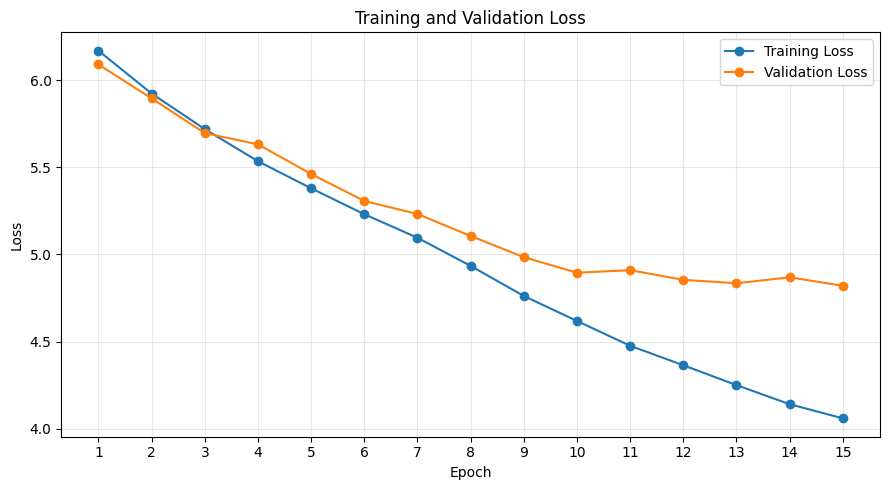

Saved: /content/drive/MyDrive/Gen AI Assignments/A1/v3/results/loss_curves.png


In [85]:
import matplotlib.pyplot as plt
import os

epochs = list(range(1, 16))

train_losses = [
    6.1696, 5.9236, 5.7193, 5.5350, 5.3798,
    5.2308, 5.0958, 4.9342, 4.7617, 4.6182,
    4.4757, 4.3639, 4.2500, 4.1404, 4.0591
]

valid_losses = [
    6.0906, 5.8954, 5.6968, 5.6319, 5.4619,
    5.3068, 5.2323, 5.1061, 4.9844, 4.8952,
    4.9098, 4.8543, 4.8346, 4.8688, 4.8202
]

plt.figure(figsize=(9, 5))

plt.plot(epochs, train_losses, marker="o", label="Training Loss")
plt.plot(epochs, valid_losses, marker="o", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.xticks(epochs)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# Save report-ready figure
results_dir = "/content/drive/MyDrive/Gen AI Assignments/A1/v3/results"
os.makedirs(results_dir, exist_ok=True)

loss_fig_path = os.path.join(results_dir, "loss_curves.png")
plt.savefig(loss_fig_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved:", loss_fig_path)

**Figure 2 — Source Length Histogram**

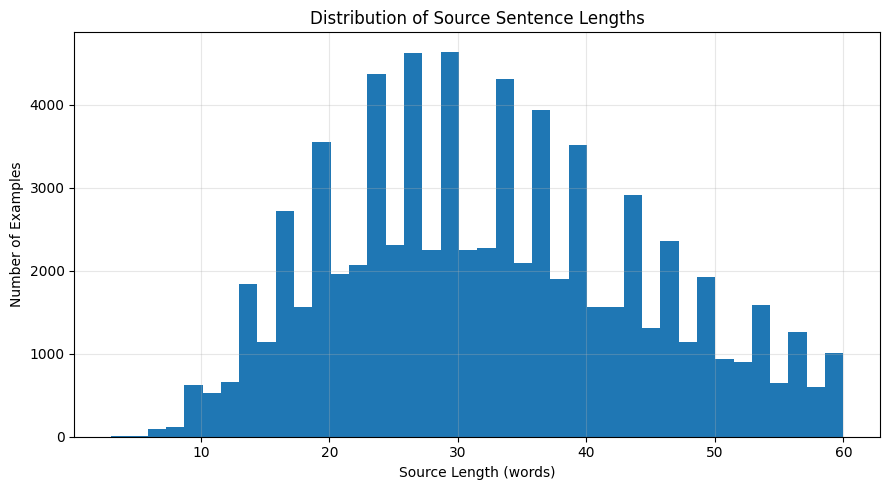

Saved: /content/drive/MyDrive/Gen AI Assignments/A1/v3/results/source_length_histogram.png


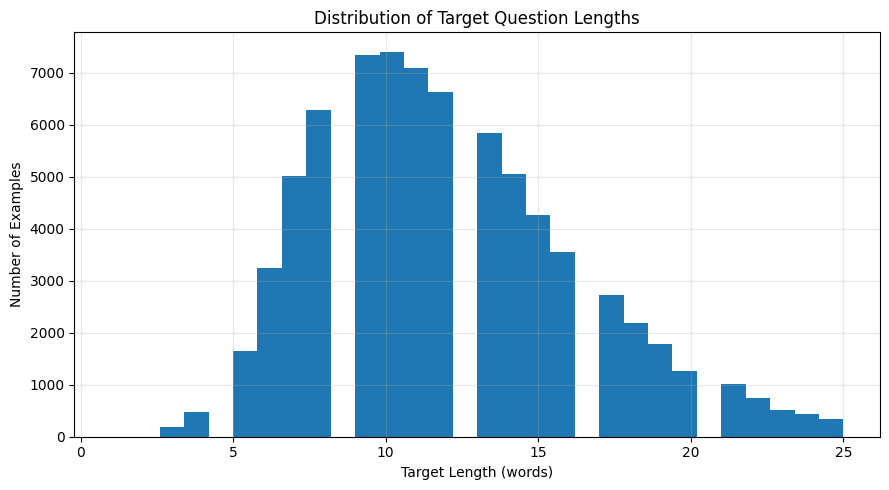

Saved: /content/drive/MyDrive/Gen AI Assignments/A1/v3/results/target_length_histogram.png


In [86]:
import matplotlib.pyplot as plt
import os

# Use the already prepared training pairs
source_lengths = train_df["source"].fillna("").str.split().str.len()
target_lengths = train_df["target"].fillna("").str.split().str.len()

results_dir = "/content/drive/MyDrive/Gen AI Assignments/A1/v3/results"
os.makedirs(results_dir, exist_ok=True)

# Source length histogram
plt.figure(figsize=(9, 5))
plt.hist(source_lengths, bins=40)
plt.xlabel("Source Length (words)")
plt.ylabel("Number of Examples")
plt.title("Distribution of Source Sentence Lengths")
plt.grid(True, alpha=0.3)
plt.tight_layout()

source_fig_path = os.path.join(results_dir, "source_length_histogram.png")
plt.savefig(source_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", source_fig_path)

# Target length histogram
plt.figure(figsize=(9, 5))
plt.hist(target_lengths, bins=30)
plt.xlabel("Target Length (words)")
plt.ylabel("Number of Examples")
plt.title("Distribution of Target Question Lengths")
plt.grid(True, alpha=0.3)
plt.tight_layout()

target_fig_path = os.path.join(results_dir, "target_length_histogram.png")
plt.savefig(target_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", target_fig_path)

**Attention heatmap cell**

/tmp/ipykernel_1314/4057026523.py:67: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1314/4057026523.py:67: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
/tmp/ipykernel_1314/4057026523.py:67: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1314/4057026523.py:67: UserWarning: Glyph 1748 (\N{ARABIC FULL STOP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1314/4057026523.py:76: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.savefig(
/tmp/ipykernel_1314/4057026523.py:76: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.savefig(
/tmp/ipykernel_1314/4057026523.py:76: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.savefig(
/tmp/ipykernel_1314/4057026523.py:76

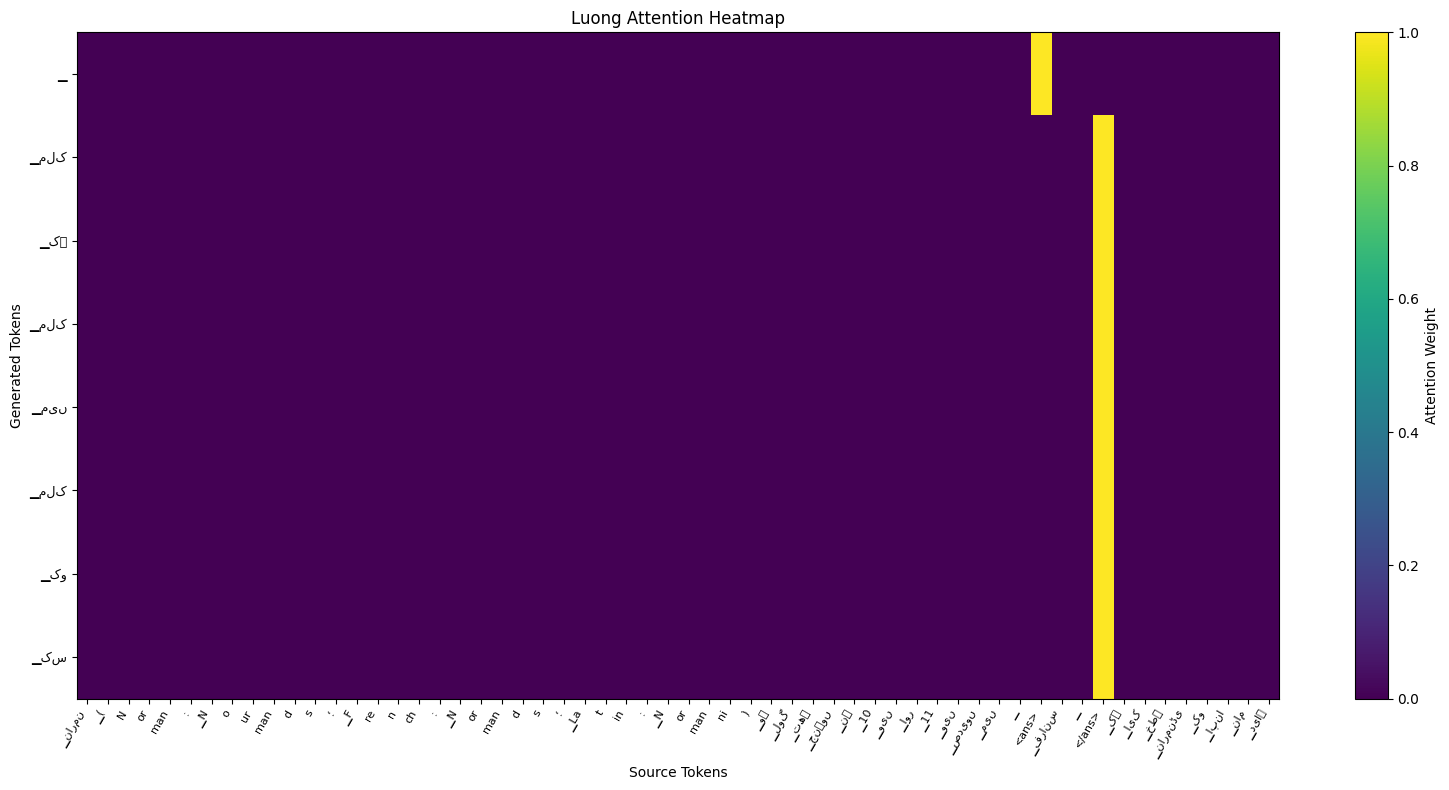

Saved: /content/drive/MyDrive/Gen AI Assignments/A1/v3/results/attention_heatmap.png
Source tokens: 58
Generated tokens: 8


In [95]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Use a font with Urdu/Arabic support
plt.rcParams["font.family"] = ["Noto Sans", "Noto Sans CJK JP"]

# Keep only actual non-padding source tokens
source_ids = src.squeeze(0).cpu().tolist()
source_tokens = [
    sp.id_to_piece(int(i))
    for i in source_ids
    if int(i) != PAD_ID
]

# Keep generated tokens excluding PAD/EOS
generated_tokens = [
    sp.id_to_piece(int(i))
    for i in generated_ids
    if int(i) not in [PAD_ID, EOS_ID]
]

# Align matrix with displayed tokens
heatmap = attention_matrix[
    :len(generated_tokens),
    :len(source_tokens)
]

# Create clean figure
fig, ax = plt.subplots(figsize=(16, 8))

im = ax.imshow(
    heatmap,
    aspect="auto",
    interpolation="nearest"
)

ax.set_xlabel("Source Tokens")
ax.set_ylabel("Generated Tokens")
ax.set_title("Luong Attention Heatmap")

# Reduce x-axis labels if there are many tokens
x_step = max(1, len(source_tokens) // 30)

ax.set_xticks(
    np.arange(0, len(source_tokens), x_step)
)
ax.set_xticklabels(
    [source_tokens[i] for i in range(0, len(source_tokens), x_step)],
    rotation=60,
    ha="right",
    fontsize=8
)

ax.set_yticks(np.arange(len(generated_tokens)))
ax.set_yticklabels(
    generated_tokens,
    fontsize=9
)

fig.colorbar(
    im,
    ax=ax,
    label="Attention Weight"
)

plt.tight_layout()

# Save report-quality figure
results_dir = "/content/drive/MyDrive/Gen AI Assignments/A1/v3/results"
attention_fig_path = os.path.join(
    results_dir,
    "attention_heatmap.png"
)

plt.savefig(
    attention_fig_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", attention_fig_path)
print("Source tokens:", len(source_tokens))
print("Generated tokens:", len(generated_tokens))